In [7]:
import numpy as np
from math import atan2, sqrt, pi
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt
from numpy.typing import NDArray
from matplotlib.patches import Circle
import warnings

# from gpa.gpa import GPA
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.dpi": 100,      
    "savefig.dpi": 300,     
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
})

In [8]:

class GPA:
    def __init__(self, matrix: NDArray[np.number]):
        """
        Gradient Pattern Analysis (GPA) implementation.

        This class implements the Gradient Pattern Analysis (GPA) method for
        two-dimensional images. Given an input image, it computes the gradient
        field, removes radially symmetric gradient vectors with respect to a
        reference center, and evaluates the four GPA moments (G1, G2, G3, and G4).

        Reference
        ---------
        Paper:

        Example
        -------
        >>> gpa = GPA(image)
        >>> gpa.setPosition(cx, cy)
        >>> results = gpa.evaluate()

        The analysis center is defined with ``setPosition(cx, cy)``, where
        ``(cx, cy)`` corresponds to the point from which radial symmetry is
        evaluated. By default, the geometric center of the image is used.

        The tolerance parameters control the removal of radially symmetric
        gradient vectors:

        The ``evaluate()`` method returns a dictionary containing the requested
        GPA moments, for example:

        >>> {
        ...     "G1": 0.81,
        ...     "G2": 0.34,
        ...     "G3": 1.25,
        ...     "G4": 4.12
        ... }

        Parameters
        ----------
        matrix : numpy.ndarray
            Two-dimensional input image :math:`I(x, y)`. The input must be a
            2D NumPy array.
        """
        
        if not np.issubdtype(matrix.dtype, np.number) or np.iscomplexobj(matrix):
            raise TypeError(
                "Input matrix must contain only real numerical values."
            )

        # The input must be two-dimensional.
        if matrix.ndim != 2:
            raise ValueError(
                "Input matrix must be two-dimensional."
            )

        # GPA requires a minimum matrix size of 3 × 3.
        if matrix.shape[0] < 3 or matrix.shape[1] < 3:
            raise ValueError(
                "Input matrix must have at least 3 rows and 3 columns."
            )

        # Convert the input matrix to float32.
        self.matrix = matrix.astype(np.float32, copy=False)

        # Image dimensions
        self.rows, self.cols = self.matrix.shape

        # Coordinates of the image center
        self.cx = (self.cols - 1) / 2
        self.cy = (self.rows - 1) / 2

        # Gradient field components:
        #
        # ∇I = (Gx, Gy)
        #
        self.gradient_dx = None
        self.gradient_dy = None

        # Gradient field after removing
        # radially symmetric vectors
        self.gradient_asymmetric_dx = None
        self.gradient_asymmetric_dy = None

        # Gradient properties:
        #
        # phases -> orientation:
        # θ = atan2(Gy, Gx)
        #
        # mods -> magnitude:
        # |∇I| = sqrt(Gx² + Gy²)
        #
        self.phases = None
        self.mods = None

        # Coordinates of the removed points and
        # the remaining asymmetric points
        self.removedP = np.empty((0, 2), dtype=np.int32)
        self.nremovedP = np.empty((0, 2), dtype=np.int32)

        # Total number of gradient vectors and
        # remaining asymmetric vectors
        self.totalVet = self.rows * self.cols
        self.totalAssimetric = self.rows * self.cols

        # Measure of gradient orientation diversity
        self.phaseDiversity = 0.0

        # Maximum gradient magnitude found in the image
        self.maxGrad = 0.0

    def setPosition(self, cx: float, cy: float):
        """
        Set the reference center used in the GPA analysis.

        If this method is not called, the geometric center of the input image
        is used by default.

        Parameters
        ----------
        cx : float
            X-coordinate of the reference center.
        cy : float
            Y-coordinate of the reference center.
        """
        self.cx = float(cx)
        self.cy = float(cy)



    def evaluate(
        self,
        magnitude_threshold=0.01,
        magnitude_tolerance=0.25,
        angle_tolerance=15,
        radial_distance_tolerance=0.5,
        symmetric_position_tolerance=0.5,
        mask=None,
        moments=["G1", "G2", "G3", "G4"],
    ):
        """
        Perform Gradient Pattern Analysis (GPA) and compute the selected
        gradient moments.

        The analysis removes radially symmetric contributions from the
        gradient field before computing the selected GPA moments.

        Parameters
        ----------
        magnitude_threshold : float, optional
            Minimum gradient magnitude threshold, expressed as a fraction
            of the maximum gradient magnitude.

        magnitude_tolerance : float, optional
            Tolerance for the difference between the magnitudes of two
            gradient vectors, expressed as a fraction of the maximum
            gradient magnitude.

        angle_tolerance : float, optional
            Angular tolerance, in radians, for considering two gradient
            vectors approximately opposite.

        radial_distance_tolerance : float, optional
            Tolerance for grouping pixels with similar radial distances.

        symmetric_position_tolerance : float, optional
            Tolerance, in pixels, for considering two pixels approximately
            symmetric with respect to the analysis center.

        mask : numpy.ndarray, optional
            Binary mask defining the valid image region. If ``None``, the
            entire image is considered.

        moments : list of str, tuple of str, str, or None, optional
            GPA moments to compute. Valid options are ``"G1"``, ``"G2"``,
            ``"G3"``, and ``"G4"``. If ``None``, all four moments are
            computed.

        Returns
        -------
        dict
            Dictionary containing the computed GPA moments, with the moment
            names as keys.

        Raises
        ------
        ValueError
            If a required parameter is ``None``, if a parameter has an
            invalid value, if the mask shape does not match the input
            matrix, or if an invalid GPA moment is requested.

        TypeError
            If ``moments`` is not a string, list, tuple, or ``None``.
        """

        if moments is None:
            moments = ["G1", "G2", "G3", "G4"]

        if magnitude_threshold is None:
            raise ValueError(
                "magnitude_threshold must be provided."
            )

        if magnitude_tolerance is None:
            raise ValueError(
                "magnitude_tolerance must be provided."
            )

        if magnitude_threshold < 0 or magnitude_threshold > 1:
            raise ValueError(
                "magnitude_threshold must be between 0 and 1."
            )

        if magnitude_tolerance < 0 or magnitude_tolerance > 1:
            raise ValueError(
                "magnitude_tolerance must be between 0 and 1."
            )

        if angle_tolerance < 0:
            raise ValueError(
                "angle_tolerance must be non-negative."
            )

        if radial_distance_tolerance < 0:
            raise ValueError(
                "radial_distance_tolerance must be non-negative."
            )

        if symmetric_position_tolerance < 0:
            raise ValueError(
                "symmetric_position_tolerance must be non-negative."
            )

        if magnitude_threshold > 0.15:
            warnings.warn(
                "magnitude_threshold is greater than 0.15. "
                "This may remove a large number of gradient vectors "
                "and affect the GPA results.",
                UserWarning
            )

        if radial_distance_tolerance > 5:
            warnings.warn(
                "radial_distance_tolerance is greater than 5. "
                "Large values may significantly increase computational "
                "cost and affect the GPA results.",
                UserWarning
            )

        if symmetric_position_tolerance > min(self.matrix.shape) / 2:
            warnings.warn(
                "symmetric_position_tolerance is large relative to "
                "the matrix size. This may affect the definition of "
                "the symmetry center.",
                UserWarning
            )

        if angle_tolerance > np.pi:
            warnings.warn(
                "angle_tolerance is greater than pi radians. "
                "This may cause a large number of gradient vectors "
                "to be considered approximately opposite.",
                UserWarning
            )

        if mask is not None:
            if mask.shape != self.matrix.shape:
                raise ValueError(
                    "mask must have the same shape as the input matrix."
                )

            self.mask = np.asarray(mask, dtype=np.float32)

        else:
            self.mask = np.ones_like(
                self.matrix,
                dtype=np.float32
            )

        if isinstance(moments, str):
            moments = [moments]

        elif isinstance(moments, tuple):
            moments = list(moments)

        elif not isinstance(moments, list):
            raise TypeError(
                "moments must be a string, list, tuple, or None."
            )

        available_moments = {
            "G1": self._G1,
            "G2": self._G2,
            "G3": self._G3,
            "G4": self._G4
        }

        for moment in moments:
            if moment not in available_moments:
                raise ValueError(
                    f"Invalid GPA moment '{moment}'. "
                    f"Available options are: "
                    f"{list(available_moments.keys())}"
                )

        # Compute the image gradient field, as well as the
        # corresponding magnitudes and orientations.
        self._setGradients()

        # Update the image dimensions
        self.cols = len(self.matrix[0])
        self.rows = len(self.matrix)

        # Compute the radial distance map:
        #
        # r = sqrt((x - cx)² + (y - cy)²)
        #
        # Each pixel is assigned its integer radial distance
        # from the analysis center.
        radial_distance_map = np.array([
            [
                int(np.sqrt((x - self.cx)**2 + (y - self.cy)**2))
                for x in range(self.cols)
            ]
            for y in range(self.rows)
        ], dtype=np.int32)

        # Retrieve the unique radial distances present in the image
        unique_radii = np.unique(radial_distance_map).astype(np.int32)

        # Remove radially symmetric gradient vectors,
        # producing the asymmetric gradient field.
        self._update_asymmetric_mat(
            unique_radii,
            radial_distance_map,
            magnitude_threshold,
            magnitude_tolerance,
            angle_tolerance,
            radial_distance_tolerance,
            symmetric_position_tolerance
        )

        # Compute the requested GPA moments
        results = {}

        for moment in moments:
            results[moment] = available_moments[moment]()

        self.radial_distance_map = radial_distance_map

        return results


        
    def _setGradients(self):
        """
        Compute the image gradient field and its associated properties.

        For an image I(x, y), the gradient is defined as:

            ∇I(x, y) = (Gx, Gy)

        where:

            Gx = ∂I/∂x

        is the intensity variation along the horizontal direction, and

            Gy = ∂I/∂y

        is the intensity variation along the vertical direction.

        The gradient magnitude is computed as:

            |∇I| = sqrt(Gx² + Gy²)

        which measures the strength of the local intensity variation.

        The gradient orientation is given by:

            θ = atan2(Gy, Gx)

        representing the angle of the gradient vector with respect to the
        x-axis.

        These quantities are subsequently used by the GPA algorithm to
        identify asymmetric structures through comparisons of gradient
        vector magnitudes and orientations.
        """

        # Compute the horizontal (gx) and vertical (gy)
        # gradients of the input image.
        #
        # gx = ∂I/∂x
        # gy = ∂I/∂y
        self.gy, self.gx = self.gradient(self.matrix)

        # Store the original gradient components.
        # These arrays remain unchanged throughout the analysis.
        self.gradient_dx = self.gx.copy()
        self.gradient_dy = self.gy.copy()

        # Create copies of the gradient components that will
        # be modified during the symmetry-removal procedure.
        self.gradient_asymmetric_dx = self.gx.copy()
        self.gradient_asymmetric_dy = self.gy.copy()

        # Compute the gradient magnitude:
        #
        # |∇I| = sqrt(Gx² + Gy²)
        self.mods = np.sqrt(self.gx**2 + self.gy**2)

        # Store the maximum gradient magnitude.
        # This value is used later for normalization:
        #
        # |∇I| / max(|∇I|)
        self.maxGrad = self.mods.max()

        # Compute the gradient orientation:
        #
        # θ = atan2(Gy, Gx)
        #
        # The result is initially in the interval [-π, π].
        angle = np.arctan2(self.gy, self.gx)

        # Convert negative angles to the interval [0, 2π].
        self.phases = np.where(
            angle >= 0,
            angle,
            angle + 2 * np.pi
        ).astype(np.float32)



    def gradient(self, matrix):
        """
        Compute the spatial gradient of a two-dimensional image using
        finite differences.

        For an image I(x, y), the gradient is defined as:

            ∇I(x, y) = (Gx, Gy)

        where:

            Gx = ∂I/∂x
            Gy = ∂I/∂y

        Central differences are used for interior pixels:

            Gx = [I(x+1, y) - I(x-1, y)] / 2
            Gy = [I(x, y+1) - I(x, y-1)] / 2

        Forward and backward differences are used at the image boundaries.

        Parameters
        ----------
        matrix : numpy.ndarray
            Two-dimensional input image.

        Returns
        -------
        tuple of numpy.ndarray
            A tuple ``(dy, dx)`` containing the vertical and horizontal
            gradient components, respectively.
        """

        # Image dimensions
        h, w = matrix.shape

        # Allocate the gradient component arrays
        dx = np.zeros((h, w), dtype=np.float32)
        dy = np.zeros((h, w), dtype=np.float32)

        # Compute the gradient at each pixel
        for j in range(h):
            for i in range(w):

                # Vertical gradient (∂I/∂y)
                #
                # Use central differences for interior pixels.
                if 0 < j < h - 1:
                    dy[j, i] = (matrix[j + 1, i] - matrix[j - 1, i]) / 2.0

                # Use forward differences along the top boundary.
                elif j < h - 1:
                    dy[j, i] = matrix[j + 1, i] - matrix[j, i]

                # Use backward differences along the bottom boundary.
                elif j > 0:
                    dy[j, i] = matrix[j, i] - matrix[j - 1, i]

                # Horizontal gradient (∂I/∂x)
                #
                # Use central differences for interior pixels.
                if 0 < i < w - 1:
                    dx[j, i] = (matrix[j, i + 1] - matrix[j, i - 1]) / 2.0

                # Use forward differences along the left boundary.
                elif i < w - 1:
                    dx[j, i] = matrix[j, i + 1] - matrix[j, i]

                # Use backward differences along the right boundary.
                elif i > 0:
                    dx[j, i] = matrix[j, i] - matrix[j, i - 1]

        return dy, dx



    def _update_asymmetric_mat(
        self,
        unique_radii,
        radial_distance_map,
        magnitude_threshold,
        magnitude_tolerance,
        angle_tolerance,
        radial_distance_tolerance,
        symmetric_position_tolerance
    ):
        """
        Remove radially symmetric contributions from the gradient field.

        Starting from the gradient field

        ```
        ∇I(x, y) = (Gx, Gy),
        ```

        the gradient magnitude and orientation are defined as

        ```
        |∇I| = sqrt(Gx² + Gy²)

        θ = atan2(Gy, Gx).
        ```

        The algorithm groups pixels according to their radial distance from
        the analysis center and compares gradient vectors within each group.

        Gradient vectors whose magnitude is below the specified relative
        threshold are first removed. The remaining vectors are then tested
        for radial symmetry.

        Two gradient vectors can be classified as a symmetric pair using
        one of two criteria.

        When `opposite_vector_tolerance` is provided, the vector-sum
        criterion is used:

        ```
        |G₁ + G₂|
        --------- <= opposite_vector_tolerance
        |G₁| + |G₂|
        ```

        This criterion directly measures how close the two vectors are to
        being equal in magnitude and opposite in direction.

        Otherwise, symmetry is determined using three conditions:

        1. Similar gradient magnitudes:

        ||∇I₁| - |∇I₂|| <= magnitude_tolerance * max(|∇I|)

        2. Approximately opposite orientations:

        |Δθ - π| <= angle_tolerance

        3. Approximately opposite spatial positions with respect to the
        analysis center:

        |x₁ + x₂ - 2cx| <= symmetric_position_tolerance

        |y₁ + y₂ - 2cy| <= symmetric_position_tolerance

        Parameters
        ----------
        unique_radii : array-like
            Unique radial distances used to group pixels.

        radial_distance_map : array-like
            Map containing the radial distance of each pixel from the analysis center.

        magnitude_threshold : float
            Minimum gradient magnitude threshold, expressed as a fraction
            of the maximum gradient magnitude.
            Note: values greater than 0.15 may result in excessive removal
            of gradient vectors, affecting the analysis.

        magnitude_tolerance : float
            Tolerance for the difference between the magnitudes of two
            gradient vectors, expressed as a fraction of the maximum
            gradient magnitude.

        angle_tolerance : float
            Angular tolerance, in radians, for considering two vectors
            approximately opposite.

        radial_distance_tolerance : float
            Tolerance, in pixels, for grouping pixels with similar radial
            distances.
            Note: very large values may affect the results and significantly
            increase computational complexity, making the algorithm extremely
            slow. Ideally, vary this parameter according to the image size,
            testing values up to 5.

        symmetric_position_tolerance : float
            Tolerance, in pixels, for considering two pixels approximately
            symmetric with respect to the analysis center.
            Note: values that are too large relative to the matrix size may
            cause the symmetry center to lose its meaning.
        """
        # Convert the arrays to the same data types used by the
        # original Cython implementation.

        mask = np.asarray(self.mask, dtype=np.float32)

        angle_tolerance = max(
            angle_tolerance,
            1,
        )

        unique_radii = np.asarray(
            unique_radii,
            dtype=np.int32
        )

        radial_distance_map = np.asarray(
            radial_distance_map,
            dtype=np.int32
        )

        # Convert the tolerance values to float32.

        angle_tolerance = np.float32(
            np.deg2rad(angle_tolerance)
        )

        radial_distance_tolerance = np.float32(
            radial_distance_tolerance
        )

        symmetric_position_tolerance = np.float32(
            symmetric_position_tolerance
        )

        removedP = []

        # Local references.
        gx = self.gradient_asymmetric_dx
        gy = self.gradient_asymmetric_dy
        mods = self.mods
        phases = self.phases

        max_grad = self.maxGrad

        # Pre-compute the coordinates of every pixel.

        yy, xx = np.indices(
            radial_distance_map.shape,
            dtype=np.int32
        )

        flat_x = xx.ravel()
        flat_y = yy.ravel()
        flat_radii = radial_distance_map.ravel()

        # Sort radial distances ONCE.
        order = np.argsort(flat_radii)
        sorted_radii = flat_radii[order]

        # Process each radial distance.

        for radius in unique_radii:

            left = np.searchsorted(
                sorted_radii,
                radius - radial_distance_tolerance,
                side="left"
            )

            right = np.searchsorted(
                sorted_radii,
                radius + radial_distance_tolerance,
                side="right"
            )

            indices = order[left:right]

            x = flat_x[indices]
            y = flat_y[indices]

            lx = len(x)

            if lx < 2:
                continue

            # Create coordinate lookup only for this radial group.
            coordinate_to_index = {
                (int(x[k]), int(y[k])): k
                for k in range(lx)
            }

            for i in range(lx):

                px = x[i]
                py = y[i]

                if mask[py, px] == 0:
                    continue

                if (
                    gx[py, px] == 0.0
                    and
                    gy[py, px] == 0.0
                ):
                    continue

                if (
                    mods[py, px] / max_grad
                ) <= magnitude_threshold:

                    gx[py, px] = np.float32(0.0)
                    gy[py, px] = np.float32(0.0)

                    continue

                target_x = 2.0 * self.cx - px
                target_y = 2.0 * self.cy - py

                candidate_indices = []

                x_min = int(
                    np.ceil(
                        target_x - symmetric_position_tolerance
                    )
                )

                x_max = int(
                    np.floor(
                        target_x + symmetric_position_tolerance
                    )
                )

                y_min = int(
                    np.ceil(
                        target_y - symmetric_position_tolerance
                    )
                )

                y_max = int(
                    np.floor(
                        target_y + symmetric_position_tolerance
                    )
                )

                for candidate_y in range(y_min, y_max + 1):

                    for candidate_x in range(x_min, x_max + 1):

                        k = coordinate_to_index.get(
                            (candidate_x, candidate_y)
                        )

                        if k is not None and k > i:
                            candidate_indices.append(k)

                # Preserve original candidate order.
                candidate_indices.sort()

                for j in candidate_indices:

                    px2 = x[j]
                    py2 = y[j]

                    if mask[py2, px2] == 0:
                        continue

                    if (
                        gx[py2, px2] == 0.0
                        and
                        gy[py2, px2] == 0.0
                    ):
                        continue

                    if (
                        abs(
                            mods[py, px]
                            - mods[py2, px2]
                        )
                        <= magnitude_tolerance * max_grad
                    ):

                        angle_opposite = (
                            abs(
                                self._angleDifference(
                                    phases[py, px],
                                    phases[py2, px2]
                                )
                                - np.pi
                            )
                            <= angle_tolerance
                        )

                        if angle_opposite:

                            gx[py, px] = np.float32(0.0)
                            gy[py, px] = np.float32(0.0)

                            gx[py2, px2] = np.float32(0.0)
                            gy[py2, px2] = np.float32(0.0)

                            break

        # Preserve compatibility with the original implementation.

        if len(removedP) > 0:
            self.removedP = np.array(
                removedP,
                dtype=np.int32
            )

        # Reset the vector counters.

        self.totalVet = 0
        self.totalAssimetric = 0

        nremovedP = []

        # Count the remaining asymmetric vectors.

        for j in range(self.rows):

            for i in range(self.cols):

                # Valid asymmetric gradient vector.

                if (
                    (
                        gy[j, i] != 0.0
                        or
                        gx[j, i] != 0.0
                    )
                    and
                    mask[j, i] != 0.0
                ):

                    nremovedP.append([j, i])

                    self.totalVet += 1

                # Gradient vector removed due to radial symmetry.

                elif mask[j, i] != 0.0:

                    removedP.append([j, i])

                    self.totalVet += 1
                    self.totalAssimetric += 1

        # Store the remaining asymmetric points.

        if len(nremovedP) > 0:

            self.nremovedP = np.array(
                nremovedP,
                dtype=np.int32
            )

    def _angleDifference(self, a1, a2):
        diff = abs(a1-a2)
        return min(diff, 2*np.pi-diff)
    

    
    def _G1(self):
        """
        Compute the first-order Gradient Pattern Analysis (G1) index.

        This implementation reproduces in Python the original first-order
        Gradient Pattern Analysis formulation introduced by Rosa, Sharma,
        and Valdivia (1999). The mathematical procedure and normalization
        used in the original implementation are preserved; only the
        programming language has been changed from the original
        implementation to Python.

        The G1 index is calculated from the Delaunay triangulation of the
        non-zero asymmetric gradient vectors. The spatial position of each
        gradient vector is combined with its normalized gradient components
        to define the points used in the triangulation.

        The number of unique Delaunay edges is compared with the total
        number of non-zero asymmetric gradient vectors according to

            G1 = (N_edges - N_asymmetric) / N_asymmetric

        where ``N_edges`` is the number of unique edges in the Delaunay
        triangulation and ``N_asymmetric`` is the number of non-zero
        asymmetric gradient vectors.

        The gradient components are rescaled using the same normalization
        factor as in the original implementation. This scaling affects only
        the spatial representation of the gradient vectors used to construct
        the asymmetric triangulation.

        References
        ----------
        Rosa, R. R., Sharma, A. S., & Valdivia, J. A. (1999).
        "Characterization of Asymmetric Fragmentation Patterns in Spatially
        Extended Systems."
        International Journal of Modern Physics C, 10(1), 147-163.
        https://doi.org/10.1142/S0129183199000103

        Notes
        -----
        This Python implementation is intended to preserve the mathematical
        formulation of the original 1999 method, rather than introduce a new
        definition of the G1 parameter.
        """
        dx = self.gradient_asymmetric_dx
        dy = self.gradient_asymmetric_dy

        # Select non-zero asymmetric gradient vectors
        naozero = np.flatnonzero(
            (dx != 0) | (dy != 0)
        )

        # Number of asymmetric gradient vectors
        self.totalAssimetric = len(naozero)

        if self.totalAssimetric < 3:

            self.n_edges = 0

            G1 = 0.0

            return G1

        # IDL factor
        factor = 1.0 / (
            2.0 * np.sqrt(
                np.abs(np.max(dx))**2 +
                np.abs(np.max(dy))**2
            )
        )

        # Convert flattened IDL indices to (row, column)
        rows, cols = np.unravel_index(
            naozero,
            dx.shape
        )

        # IDL:
        #
        # vvx = dx(naozero)*factor + naozero MOD my
        # vvy = dy(naozero)*factor + naozero/my

        self.vvx = (
            dx[rows, cols] * factor
            + cols
        )

        self.vvy = (
            dy[rows, cols] * factor
            + rows
        )

        # Delaunay triangulation
        triangulation_points = np.column_stack(
            (self.vvx, self.vvy)
        ).astype(np.float64)

        self.triangles = Delaunay(
            triangulation_points
        )

        # Number of unique Delaunay edges
        indptr, indices = (
            self.triangles.vertex_neighbor_vertices
        )

        self.n_edges = len(indices) / 2.0

        # GPA / Fragmentation
        G1 = (
            self.n_edges - self.totalAssimetric
        ) / self.totalAssimetric

        return G1

    def _G2(self):
        """
        Compute the second Gradient Pattern Analysis (GPA) moment.

        The second GPA moment is defined as

            G2 = (V / VA) · (2 - D)

        where

            V  = number of remaining asymmetric gradient vectors,
            VA = total number of valid gradient vectors, and

            D = |Σvi| / Σ|vi|

        is the vectorial diversity (or alignment) measure. Values of
        ``D`` close to 1 indicate highly aligned gradient vectors,
        whereas smaller values indicate greater directional diversity.

        Returns
        -------
        float
            The second GPA moment (G2).
        """

        # Count the remaining asymmetric gradient vectors.
        if len(self.nremovedP) > 0:
            self.totalAssimetric = len(self.nremovedP[:, 0])
        else:
            self.totalAssimetric = 0

        # Compute the vectorial diversity:
        #
        # D = |Σvi| / Σ|vi|
        self.phaseDiversity = self._vectorialVariety()

        # Compute the second GPA moment:
        #
        # G2 = (V / VA) · (2 - D)
        G2 = (
            float(self.totalAssimetric) / float(self.totalVet)
        ) * (2.0 - self.phaseDiversity)

        return G2

    
    def _G3(self):
            
        return
    def _G4(self):
            
        return

    def _vectorialVariety(self):
        """
        Compute the vectorial diversity (alignment) measure.

        The quantity is defined as

            D = |Σvi| / Σ|vi|

        where

            vi = (Gx, Gy)

        is an asymmetric gradient vector.

        This measure quantifies the overall alignment of the asymmetric
        gradient vectors. Values close to 1 indicate that the vectors are
        predominantly aligned in the same direction, whereas values close
        to 0 indicate a more diverse or isotropic distribution of
        orientations.

        Returns
        -------
        float
            The vectorial diversity (alignment) measure.
        """

        sum_x = 0.0
        sum_y = 0.0
        sum_magnitude = 0.0

        # No asymmetric vectors are available.
        if self.totalAssimetric < 1:
            return 0.0

        # Sum the asymmetric gradient vectors.
        for i in range(self.totalAssimetric):

            row = self.nremovedP[i, 0]
            col = self.nremovedP[i, 1]

            # Gradient magnitude:
            #
            # |vi| = sqrt(Gx² + Gy²)
            magnitude = self.mods[row, col]

            sum_x += self.gradient_dx[row, col]
            sum_y += self.gradient_dy[row, col]

            # Sum of the vector magnitudes.
            sum_magnitude += magnitude

        if sum_magnitude <= 0.0:
            return 0.0

        # Compute the vectorial diversity:
        #
        # D = sqrt((ΣGx)² + (ΣGy)²) / Σ|vi|
        vectorial_diversity = (
            np.sqrt(sum_x**2 + sum_y**2) / sum_magnitude
        )

        return vectorial_diversity



    def plot_delaunay_triangulation(
        self,
        show_image=True,
        show_scale=True,
        show_center=True,
        line_color="red"
    ):
        """
        Plot the asymmetric gradient field and its Delaunay triangulation.

        The triangulation is constructed from the positions of the
        remaining asymmetric gradient vectors.

        Parameters
        ----------
        show_image : bool, default=True
            If True, display the original matrix as the background.

        show_scale : bool, default=True
            If True, display the x and y axes, including tick marks
            and labels. If False, hide the ticks and labels while
            preserving the plot area.

        show_center : bool, default=True
            If True, display the analysis center.

        line_color : str, default="red"
            Color of the Delaunay triangulation lines.
        """

        gx = self.gradient_asymmetric_dx
        gy = self.gradient_asymmetric_dy

        valid = (
            self.mask.astype(bool)
            & ((gx != 0) | (gy != 0))
        )

        has_vectors = np.any(valid)

        # Pixel-centered coordinates
        y, x = np.mgrid[
            0:self.rows,
            0:self.cols
        ]

        x = x + 0.5
        y = y + 0.5

        # Determine plotting region
        if max(self.rows, self.cols) > 50 and has_vectors:

            rows, cols = np.where(valid)

            margin = 2

            ymin = max(rows.min() - margin, 0)
            ymax = min(rows.max() + margin + 1, self.rows)

            xmin = max(cols.min() - margin, 0)
            xmax = min(cols.max() + margin + 1, self.cols)

        else:

            ymin = 0
            ymax = self.rows

            xmin = 0
            xmax = self.cols

        if not has_vectors:

            print("No asymmetric gradient vectors remaining.")
            return

        # Not enough points for Delaunay triangulation
        if not hasattr(self, "vvx") or len(self.vvx) < 3:

            print(
                "Not enough asymmetric gradient vectors "
                "for Delaunay triangulation."
            )

            return

        # Figure
        fig, ax = plt.subplots(figsize=(5, 5))

        # Background image
        if show_image:

            ax.imshow(
                self.matrix[ymin:ymax, xmin:xmax],
                cmap="gray",
                origin="lower",
                extent=[
                    xmin,
                    xmax,
                    ymin,
                    ymax
                ]
            )

        # Normalize vectors for visualization
        max_gx = np.max(np.abs(gx))
        max_gy = np.max(np.abs(gy))

        factor = 1.0 / (
            2.0 * np.sqrt(
                max_gx**2 +
                max_gy**2
            )
        )

        u = gx * factor
        v = gy * factor

        # Asymmetric gradient vectors
        ax.quiver(
            x[valid],
            y[valid],
            u[valid],
            v[valid],
            color=line_color,
            angles="xy",
            scale_units="xy",
            scale=1
        )

        # Delaunay triangulation
        ax.triplot(
            self.vvx + 0.5,
            self.vvy + 0.5,
            self.triangles.simplices,
            color=line_color,
            linewidth=0.8
        )

        # Triangulation points
        ax.scatter(
            self.vvx + 0.5,
            self.vvy + 0.5,
            s=8,
            color=line_color,
            zorder=3
        )

        # Analysis center
        if show_center:

            ax.scatter(
                self.cx + 0.5,
                self.cy + 0.5,
                marker="x",
                color="blue",
                s=100,
                linewidths=2,
                zorder=4
            )

        # Plot limits
        margin = 0.5

        ax.set_xlim(
            xmin - margin,
            xmax + margin
        )

        ax.set_ylim(
            ymin - margin,
            ymax + margin
        )

        # Minimal style
        if show_scale:

            ax.set_xlabel("x [pixel]")
            ax.set_ylabel("y [pixel]")

            # Last pixel in the displayed region
            xmax_pixel = xmax - 1
            ymax_pixel = ymax - 1

            # Number of pixels in the displayed region
            width = xmax_pixel - xmin + 1
            height = ymax_pixel - ymin + 1

            # Generate integer pixel coordinates
            if width <= 15:

                xticks = np.arange(
                    xmin,
                    xmax_pixel + 1
                )

            else:

                xticks = np.linspace(
                    xmin,
                    xmax_pixel,
                    15
                ).round().astype(int)

                xticks = np.unique(xticks)

            if height <= 15:

                yticks = np.arange(
                    ymin,
                    ymax_pixel + 1
                )

            else:

                yticks = np.linspace(
                    ymin,
                    ymax_pixel,
                    15
                ).round().astype(int)

                yticks = np.unique(yticks)

            # Place ticks at the center of each pixel
            ax.set_xticks(xticks + 0.5)
            ax.set_yticks(yticks + 0.5)

            # Show all labels for small images
            if width <= 15:

                ax.set_xticklabels([
                    str(value) for value in xticks
                ])

            else:

                # Show only 3 labels
                xlabels = np.linspace(
                    0,
                    len(xticks) - 1,
                    3
                ).round().astype(int)

                # Always show zero when present
                zero_index = np.where(xticks == 0)[0]

                if len(zero_index) > 0:

                    xlabels = np.unique(
                        np.append(
                            xlabels,
                            zero_index[0]
                        )
                    )

                ax.set_xticklabels([
                    str(xticks[i]) if i in xlabels else ""
                    for i in range(len(xticks))
                ])

            if height <= 15:

                ax.set_yticklabels([
                    str(value) for value in yticks
                ])

            else:

                # Show only 3 labels
                ylabels = np.linspace(
                    0,
                    len(yticks) - 1,
                    3
                ).round().astype(int)

                # Always show zero when present
                zero_index = np.where(yticks == 0)[0]

                if len(zero_index) > 0:

                    ylabels = np.unique(
                        np.append(
                            ylabels,
                            zero_index[0]
                        )
                    )

                ax.set_yticklabels([
                    str(yticks[i]) if i in ylabels else ""
                    for i in range(len(yticks))
                ])

            # Remove plot borders
            for spine in ax.spines.values():

                spine.set_visible(False)

        else:

            # Remove ticks and labels
            ax.set_xticks([])
            ax.set_yticks([])

            ax.set_xlabel("")
            ax.set_ylabel("")

            # Keep plot boundary
            for spine in ax.spines.values():

                spine.set_visible(True)
                spine.set_linewidth(0.8)

        ax.set_aspect("equal")

        plt.tight_layout(pad=0)

        plt.show()

    def plot_gradient_field(
        self,
        fixed_length=True,
        show_image=True,
        show_scale=True,
        show_center=True,
        color="red"
    ):
        """
        Plot the image gradient field as a vector field.

        Each arrow represents a gradient vector:

            ∇I = (Gx, Gy)

        Parameters
        ----------
        fixed_length : bool, default=True
            If True, normalize all vectors to the same length so that
            only their orientations are represented. If False, preserve
            the relative gradient magnitudes.

        show_image : bool, default=True
            If True, display the original matrix as the background
            of the gradient field.

        show_scale : bool, default=True
            If True, display the x and y axes, including tick marks
            and labels. If False, hide the ticks and labels while
            preserving the plot area.

        show_center : bool, default=True
            If True, display the analysis center.

        color : str, default="red"
            Color of the gradient vectors.
        """

        # Pixels where vectors will be displayed
        valid = self.mask.astype(bool)

        gx = self.gradient_dx
        gy = self.gradient_dy

        # Coordinate grid
        y, x = np.mgrid[
            0:self.rows,
            0:self.cols
        ]

        x = x + 0.5
        y = y + 0.5

        # Normalize vectors or preserve magnitudes
        if fixed_length:

            magnitude = np.sqrt(gx**2 + gy**2)

            # Avoid division by zero
            magnitude[magnitude == 0] = 1

            scale = 0.5

            u = (gx / magnitude) * scale
            v = (gy / magnitude) * scale

        else:

            max_gx = np.max(np.abs(gx))
            max_gy = np.max(np.abs(gy))

            factor = 1.0 / (
                2.0 * np.sqrt(
                    max_gx**2 +
                    max_gy**2
                )
            )

            u = gx * factor
            v = gy * factor

        # Bounding box of the mask
        rows, cols = np.where(valid)

        margin = 2

        ymin = max(rows.min() - margin, 0)
        ymax = min(rows.max() + margin + 1, self.rows)

        xmin = max(cols.min() - margin, 0)
        xmax = min(cols.max() + margin + 1, self.cols)

        # Figure
        fig, ax = plt.subplots(figsize=(5, 5))

        # Background image
        if show_image:

            ax.imshow(
                self.matrix[ymin:ymax, xmin:xmax],
                cmap="gray",
                origin="lower",
                extent=[
                    xmin,
                    xmax,
                    ymin,
                    ymax
                ]
            )

        # Gradient vectors
        ax.quiver(
            x[valid],
            y[valid],
            u[valid],
            v[valid],
            color=color,
            angles="xy",
            scale_units="xy",
            scale=1
        )

        # Analysis center
        if show_center:

            ax.scatter(
                self.cx + 0.5,
                self.cy + 0.5,
                marker="x",
                color="blue",
                s=150,
                linewidths=2
            )

        # Plot limits
        margin = 0.5

        ax.set_xlim(xmin - margin, xmax + margin)
        ax.set_ylim(ymin - margin, ymax + margin)

        # Minimal style
        if show_scale:

            ax.set_xlabel("x [pixel]")
            ax.set_ylabel("y [pixel]")

            # Last pixel in the displayed region
            xmax_pixel = xmax - 1
            ymax_pixel = ymax - 1

            # Number of pixels in the displayed region
            width = xmax_pixel - xmin + 1
            height = ymax_pixel - ymin + 1

            # Generate integer pixel coordinates
            if width <= 15:

                xticks = np.arange(
                    xmin,
                    xmax_pixel + 1
                )

            else:

                xticks = np.linspace(
                    xmin,
                    xmax_pixel,
                    15
                ).round().astype(int)

                xticks = np.unique(xticks)

            if height <= 15:

                yticks = np.arange(
                    ymin,
                    ymax_pixel + 1
                )

            else:

                yticks = np.linspace(
                    ymin,
                    ymax_pixel,
                    15
                ).round().astype(int)

                yticks = np.unique(yticks)

            # Place ticks at the center of each pixel
            ax.set_xticks(xticks + 0.5)
            ax.set_yticks(yticks + 0.5)

            # Show all labels for small images
            if width <= 15:

                ax.set_xticklabels([
                    str(value) for value in xticks
                ])

            else:

                # Show only 3 labels
                xlabels = np.linspace(
                    0,
                    len(xticks) - 1,
                    3
                ).round().astype(int)

                # Always show zero when present
                zero_index = np.where(xticks == 0)[0]

                if len(zero_index) > 0:

                    xlabels = np.unique(
                        np.append(
                            xlabels,
                            zero_index[0]
                        )
                    )

                ax.set_xticklabels([
                    str(xticks[i]) if i in xlabels else ""
                    for i in range(len(xticks))
                ])

            if height <= 15:

                ax.set_yticklabels([
                    str(value) for value in yticks
                ])

            else:

                # Show only 3 labels
                ylabels = np.linspace(
                    0,
                    len(yticks) - 1,
                    3
                ).round().astype(int)

                # Always show zero when present
                zero_index = np.where(yticks == 0)[0]

                if len(zero_index) > 0:

                    ylabels = np.unique(
                        np.append(
                            ylabels,
                            zero_index[0]
                        )
                    )

                ax.set_yticklabels([
                    str(yticks[i]) if i in ylabels else ""
                    for i in range(len(yticks))
                ])

            # Remove plot borders
            for spine in ax.spines.values():
                spine.set_visible(False)

        else:

            # Remove ticks and labels
            ax.set_xticks([])
            ax.set_yticks([])

            ax.set_xlabel("")
            ax.set_ylabel("")

            # Keep the boundary of the image/plot
            for spine in ax.spines.values():

                spine.set_visible(True)
                spine.set_linewidth(0.8)

        ax.set_aspect("equal")

        plt.tight_layout(pad=0)

        plt.show()

    def plot_asymmetric_gradient_field(
        self,
        fixed_length=True,
        show_image=True,
        show_scale=True,
        show_center=True,
        color="red"
    ):
        """
        Plot the asymmetric gradient field obtained after removing
        symmetric gradient contributions.

        Parameters
        ----------
        fixed_length : bool, default=True
            If True, normalize all vectors to the same length so that
            only their orientations are represented. If False, preserve
            the relative gradient magnitudes.

        show_image : bool, default=True
            If True, display the original matrix as the background
            of the gradient field.

        show_scale : bool, default=True
            If True, display the x and y axes, including tick marks
            and labels. If False, hide the ticks and labels while
            preserving the plot area.

        show_center : bool, default=True
            If True, display the analysis center used to identify
            symmetric gradient contributions.

        color : str, default="red"
            Color of the asymmetric gradient vectors.
        """

        gx = self.gradient_asymmetric_dx
        gy = self.gradient_asymmetric_dy

        valid = (
            self.mask.astype(bool)
            & ((gx != 0) | (gy != 0))
        )

        has_vectors = np.any(valid)

        # Coordinate grid
        y, x = np.mgrid[
            0:self.rows,
            0:self.cols
        ]

        x = x + 0.5
        y = y + 0.5

        # Determine plotting region
        if max(self.rows, self.cols) > 50 and has_vectors:

            rows, cols = np.where(valid)

            margin = 2

            ymin = max(rows.min() - margin, 0)
            ymax = min(rows.max() + margin + 1, self.rows)

            xmin = max(cols.min() - margin, 0)
            xmax = min(cols.max() + margin + 1, self.cols)

        else:

            ymin = 0
            ymax = self.rows

            xmin = 0
            xmax = self.cols

        # Normalize vectors if requested
        if has_vectors:

            if fixed_length:

                magnitude = np.sqrt(gx**2 + gy**2)

                # Avoid division by zero
                magnitude[magnitude == 0] = 1

                scale = 0.5

                u = (gx / magnitude) * scale
                v = (gy / magnitude) * scale

            else:

                max_gx = np.max(np.abs(gx))
                max_gy = np.max(np.abs(gy))

                factor = 1.0 / (
                    2.0 * np.sqrt(
                        max_gx**2 +
                        max_gy**2
                    )
                )

                u = gx * factor
                v = gy * factor

        else:

            print("No asymmetric gradient vectors remaining.")

            return

        # Figure
        fig, ax = plt.subplots(figsize=(5, 5))

        # Background image
        if show_image:

            ax.imshow(
                self.matrix[ymin:ymax, xmin:xmax],
                cmap="gray",
                origin="lower",
                extent=[
                    xmin,
                    xmax,
                    ymin,
                    ymax
                ]
            )

        # Asymmetric gradient vectors
        ax.quiver(
            x[valid],
            y[valid],
            u[valid],
            v[valid],
            color=color,
            angles="xy",
            scale_units="xy",
            scale=1
        )

        # Analysis center
        if show_center:

            ax.scatter(
                self.cx + 0.5,
                self.cy + 0.5,
                marker="x",
                color="blue",
                s=150,
                linewidths=2,
                zorder=4
            )

        # Plot limits
        margin = 0.5

        ax.set_xlim(
            xmin - margin,
            xmax + margin
        )

        ax.set_ylim(
            ymin - margin,
            ymax + margin
        )

        # Scale and ticks
        if show_scale:

            ax.set_xlabel("x [pixel]")
            ax.set_ylabel("y [pixel]")

            # Last pixel in the displayed region
            xmax_pixel = xmax - 1
            ymax_pixel = ymax - 1

            # Number of pixels in the displayed region
            width = xmax_pixel - xmin + 1
            height = ymax_pixel - ymin + 1

            # Generate integer pixel coordinates
            if width <= 15:

                xticks = np.arange(
                    xmin,
                    xmax_pixel + 1
                )

            else:

                xticks = np.linspace(
                    xmin,
                    xmax_pixel,
                    15
                ).round().astype(int)

                xticks = np.unique(xticks)

            if height <= 15:

                yticks = np.arange(
                    ymin,
                    ymax_pixel + 1
                )

            else:

                yticks = np.linspace(
                    ymin,
                    ymax_pixel,
                    15
                ).round().astype(int)

                yticks = np.unique(yticks)

            # Place ticks at the center of each pixel
            ax.set_xticks(xticks + 0.5)
            ax.set_yticks(yticks + 0.5)

            # Show all labels for small images
            if width <= 15:

                ax.set_xticklabels([
                    str(value)
                    for value in xticks
                ])

            else:

                # Show only 3 labels
                xlabels = np.linspace(
                    0,
                    len(xticks) - 1,
                    3
                ).round().astype(int)

                # Always show zero when present
                zero_index = np.where(
                    xticks == 0
                )[0]

                if len(zero_index) > 0:

                    xlabels = np.unique(
                        np.append(
                            xlabels,
                            zero_index[0]
                        )
                    )

                ax.set_xticklabels([
                    str(xticks[i])
                    if i in xlabels
                    else ""
                    for i in range(len(xticks))
                ])

            if height <= 15:

                ax.set_yticklabels([
                    str(value)
                    for value in yticks
                ])

            else:

                # Show only 3 labels
                ylabels = np.linspace(
                    0,
                    len(yticks) - 1,
                    3
                ).round().astype(int)

                # Always show zero when present
                zero_index = np.where(
                    yticks == 0
                )[0]

                if len(zero_index) > 0:

                    ylabels = np.unique(
                        np.append(
                            ylabels,
                            zero_index[0]
                        )
                    )

                ax.set_yticklabels([
                    str(yticks[i])
                    if i in ylabels
                    else ""
                    for i in range(len(yticks))
                ])

            # Remove plot borders
            for spine in ax.spines.values():
                spine.set_visible(False)

        else:

            # Remove ticks and labels
            ax.set_xticks([])
            ax.set_yticks([])

            ax.set_xlabel("")
            ax.set_ylabel("")

            # Keep the plot boundary
            for spine in ax.spines.values():

                spine.set_visible(True)
                spine.set_linewidth(0.8)

        ax.set_aspect("equal")

        plt.tight_layout(pad=0)

        plt.show()




    def plot_single_radius_group(
        self,
        radius,
        radial_distance_tolerance,
        fixed_length=True,
        show_image=True,
        show_scale=True,
        show_center=True
    ):
        """
        Highlight a radial group over the gradient field.

        The complete gradient field is displayed in light gray.
        Gradient vectors belonging to the selected radial group are
        highlighted in red, together with the corresponding radial
        circle.

        Parameters
        ----------
        radius : float
            Radial distance defining the center of the selected group.

        radial_distance_tolerance : float
            Tolerance used to determine which pixels belong to the
            selected radial group.

        fixed_length : bool, default=True
            If True, normalize all vectors to the same length.
            If False, preserve the relative gradient magnitudes.

        show_image : bool, default=True
            If True, display the original matrix as the background.

        show_scale : bool, default=True
            If True, display the x and y axes, including tick marks
            and labels.

        show_center : bool, default=True
            If True, display the analysis center.
        """

        # Pixels where vectors will be displayed

        valid = self.mask.astype(bool)

        gx = self.gradient_dx
        gy = self.gradient_dy

        # Selected radial group

        group = (
            valid
            &
            (
                np.abs(
                    self.radial_distance_map - radius
                )
                <= radial_distance_tolerance
            )
        )

        # Coordinate grid

        y, x = np.mgrid[
            0:self.rows,
            0:self.cols
        ]

        x = x + 0.5
        y = y + 0.5

        # Normalize vectors

        if fixed_length:

            magnitude = np.sqrt(
                gx**2 +
                gy**2
            )

            magnitude[magnitude == 0] = 1

            scale = 0.5

            u = (gx / magnitude) * scale
            v = (gy / magnitude) * scale

        else:

            max_gx = np.max(np.abs(gx))
            max_gy = np.max(np.abs(gy))

            factor = 1.0 / (
                2.0 * np.sqrt(
                    max_gx**2 +
                    max_gy**2
                )
            )

            u = gx * factor
            v = gy * factor

        # Bounding box of the mask

        rows, cols = np.where(valid)

        margin = 2

        ymin = max(
            rows.min() - margin,
            0
        )

        ymax = min(
            rows.max() + margin + 1,
            self.rows
        )

        xmin = max(
            cols.min() - margin,
            0
        )

        xmax = min(
            cols.max() + margin + 1,
            self.cols
        )

        # Figure

        fig, ax = plt.subplots(
            figsize=(5, 5)
        )

        # Background image

        if show_image:

            ax.imshow(
                self.matrix[
                    ymin:ymax,
                    xmin:xmax
                ],
                cmap="gray",
                origin="lower",
                extent=[
                    xmin,
                    xmax,
                    ymin,
                    ymax
                ]
            )

        # Complete gradient field

        ax.quiver(
            x[valid],
            y[valid],
            u[valid],
            v[valid],
            color="lightgray",
            angles="xy",
            scale_units="xy",
            scale=1
        )

        # Selected radial group

        ax.quiver(
            x[group],
            y[group],
            u[group],
            v[group],
            color="red",
            angles="xy",
            scale_units="xy",
            scale=1,
            zorder=3
        )

        # Radial circle

        circle = Circle(
            (
                self.cx + 0.5,
                self.cy + 0.5
            ),
            radius,
            fill=False,
            edgecolor="red",
            linestyle="--",
            linewidth=1.5,
            zorder=2
        )

        ax.add_patch(circle)

        # Analysis center

        if show_center:

            ax.scatter(
                self.cx + 0.5,
                self.cy + 0.5,
                marker="x",
                color="blue",
                s=150,
                linewidths=2,
                zorder=4
            )

        # Plot limits

        margin = 0.5

        ax.set_xlim(
            xmin - margin,
            xmax + margin
        )

        ax.set_ylim(
            ymin - margin,
            ymax + margin
        )

        # Minimal style

        if show_scale:

            ax.set_xlabel("x")
            ax.set_ylabel("y")

        else:

            ax.set_xticks([])
            ax.set_yticks([])

            ax.set_xlabel("")
            ax.set_ylabel("")

            for spine in ax.spines.values():

                spine.set_visible(True)
                spine.set_linewidth(0.8)

        ax.set_aspect("equal")

        plt.tight_layout(pad=0)

        plt.show()

    def plot_vector_pair(
        self,
        p1,
        p2,
        fixed_length=True,
        show_image=True,
        show_scale=True,
        show_center=True
    ):
        """
        Highlight two candidate gradient vectors over the complete
        gradient field.

        The first vector is highlighted in red and the second vector
        in green. The remaining gradient vectors are displayed in
        light gray.

        Parameters
        ----------
        p1 : tuple
            Coordinates of the first vector as ``(py, px)``.

        p2 : tuple
            Coordinates of the second vector as ``(py, px)``.

        fixed_length : bool, default=True
            If True, normalize all vectors to the same length.
            If False, preserve the relative gradient magnitudes.

        show_image : bool, default=True
            If True, display the original matrix as the background.

        show_scale : bool, default=True
            If True, display the x and y axes, including tick marks
            and labels.

        show_center : bool, default=True
            If True, display the analysis center.
        """

        # Gradient field

        valid = self.mask.astype(bool)

        gx = self.gradient_dx
        gy = self.gradient_dy

        # Coordinate grid

        y, x = np.mgrid[
            0:self.rows,
            0:self.cols
        ]

        x = x + 0.5
        y = y + 0.5

        # Normalize vectors

        if fixed_length:

            magnitude = np.sqrt(
                gx**2 +
                gy**2
            )

            magnitude[magnitude == 0] = 1

            scale = 0.5

            u = (gx / magnitude) * scale
            v = (gy / magnitude) * scale

        else:

            max_gx = np.max(np.abs(gx))
            max_gy = np.max(np.abs(gy))

            factor = 1.0 / (
                2.0 * np.sqrt(
                    max_gx**2 +
                    max_gy**2
                )
            )

            u = gx * factor
            v = gy * factor

        # Bounding box of the mask

        rows, cols = np.where(valid)

        margin = 2

        ymin = max(
            rows.min() - margin,
            0
        )

        ymax = min(
            rows.max() + margin + 1,
            self.rows
        )

        xmin = max(
            cols.min() - margin,
            0
        )

        xmax = min(
            cols.max() + margin + 1,
            self.cols
        )

        # Figure

        fig, ax = plt.subplots(
            figsize=(5, 5)
        )

        # Background image

        if show_image:

            ax.imshow(
                self.matrix[
                    ymin:ymax,
                    xmin:xmax
                ],
                cmap="gray",
                origin="lower",
                extent=[
                    xmin,
                    xmax,
                    ymin,
                    ymax
                ]
            )

        # Complete gradient field

        ax.quiver(
            x[valid],
            y[valid],
            u[valid],
            v[valid],
            color="lightgray",
            angles="xy",
            scale_units="xy",
            scale=1
        )

        # First candidate vector

        py1, px1 = p1

        ax.quiver(
            px1 + 0.5,
            py1 + 0.5,
            u[py1, px1],
            v[py1, px1],
            color="red",
            angles="xy",
            scale_units="xy",
            scale=1,
            width=0.008,
            zorder=4
        )

        circle1 = Circle(
            (
                px1 + 0.5,
                py1 + 0.5
            ),
            radius=1,
            fill=False,
            edgecolor="lightblue",
            linewidth=2,
            zorder=5
        )

        ax.add_patch(circle1)


        # Second candidate vector

        py2, px2 = p2

        ax.quiver(
            px2 + 0.5,
            py2 + 0.5,
            u[py2, px2],
            v[py2, px2],
            color="red",
            angles="xy",
            scale_units="xy",
            scale=1,
            width=0.008,
            zorder=4
        )

        circle2 = Circle(
            (
                px2 + 0.5,
                py2 + 0.5
            ),
            radius=1,
            fill=False,
            edgecolor="lightblue",
            linewidth=2,
            zorder=5
        )

        ax.add_patch(circle2)

        # Analysis center

        if show_center:

            ax.scatter(
                self.cx + 0.5,
                self.cy + 0.5,
                marker="x",
                color="blue",
                s=150,
                linewidths=2,
                zorder=6
            )

        # Plot limits

        margin = 0.5

        ax.set_xlim(
            xmin - margin,
            xmax + margin
        )

        ax.set_ylim(
            ymin - margin,
            ymax + margin
        )

        # Minimal style

        if show_scale:

            ax.set_xlabel("x")
            ax.set_ylabel("y")

        else:

            ax.set_xticks([])
            ax.set_yticks([])

            ax.set_xlabel("")
            ax.set_ylabel("")

            for spine in ax.spines.values():

                spine.set_visible(True)
                spine.set_linewidth(0.8)

        ax.set_aspect("equal")

        plt.tight_layout(pad=0)

        plt.show()


    def plot_radial_group_pair(
        self,
        radius,
        radial_distance_tolerance,
        p1,
        p2,
        fixed_length=True,
        show_image=True,
        show_scale=True,
        show_center=True
    ):
        """
        Highlight a radial group and two candidate gradient vectors.

        The complete gradient field is displayed in light gray.
        Gradient vectors belonging to the selected radial group are
        highlighted in red. The two candidate vectors within this
        group are highlighted individually in blue and green.

        The selected radial distance is represented by a red dashed
        circle centered on the analysis center.

        Parameters
        ----------
        radius : float
            Radial distance defining the selected radial group.

        radial_distance_tolerance : float
            Tolerance used to determine which pixels belong to the
            selected radial group.

        p1 : tuple
            Coordinates of the first candidate vector as ``(py, px)``.

        p2 : tuple
            Coordinates of the second candidate vector as ``(py, px)``.

        fixed_length : bool, default=True
            If True, normalize all vectors to the same length.
            If False, preserve the relative gradient magnitudes.

        show_image : bool, default=True
            If True, display the original matrix as the background.

        show_scale : bool, default=True
            If True, display the x and y axes, including tick marks
            and labels.

        show_center : bool, default=True
            If True, display the analysis center.
        """

        # Gradient field

        valid = self.mask.astype(bool)

        gx = self.gradient_dx
        gy = self.gradient_dy

        # Selected radial group

        group = (
            valid
            &
            (
                np.abs(
                    self.radial_distance_map - radius
                )
                <= radial_distance_tolerance
            )
        )

        # Coordinate grid

        y, x = np.mgrid[
            0:self.rows,
            0:self.cols
        ]

        x = x + 0.5
        y = y + 0.5

        # Normalize vectors

        magnitude = np.sqrt(
            gx**2 +
            gy**2
        )

        if fixed_length:

            magnitude_safe = magnitude.copy()
            magnitude_safe[magnitude_safe == 0] = 1

            scale = 0.6

            u = (
                gx /
                magnitude_safe
            ) * scale

            v = (
                gy /
                magnitude_safe
            ) * scale

        else:

            max_gx = np.max(
                np.abs(gx)
            )

            max_gy = np.max(
                np.abs(gy)
            )

            denominator = (
                2.0 *
                np.sqrt(
                    max_gx**2 +
                    max_gy**2
                )
            )

            if denominator == 0:

                print("No gradient vectors available.")
                return

            factor = 1.0 / denominator

            u = gx * factor
            v = gy * factor

        # Bounding box of the mask

        rows, cols = np.where(valid)

        margin = 2

        ymin = max(
            rows.min() - margin,
            0
        )

        ymax = min(
            rows.max() + margin + 1,
            self.rows
        )

        xmin = max(
            cols.min() - margin,
            0
        )

        xmax = min(
            cols.max() + margin + 1,
            self.cols
        )

        # Figure

        fig, ax = plt.subplots(
            figsize=(5, 5)
        )

        # Background image

        if show_image:

            ax.imshow(
                self.matrix[
                    ymin:ymax,
                    xmin:xmax
                ],
                cmap="gray",
                origin="lower",
                extent=[
                    xmin,
                    xmax,
                    ymin,
                    ymax
                ]
            )

        # Complete gradient field

        # Complete gradient field
        ax.quiver(
            x[valid],
            y[valid],
            u[valid],
            v[valid],
            color="gray",
            angles="xy",
            scale_units="xy",
            scale=1
        )

        # Selected radial group
        ax.quiver(
            x[group],
            y[group],
            u[group],
            v[group],
            color="red",
            angles="xy",
            scale_units="xy",
            scale=1,
            zorder=3
        )

        # Radial circle

        # Radial comparison path
        # continuous -> dotted -> continuous -> arrow

        cx_plot = self.cx + 0.5
        cy_plot = self.cy + 0.5

        py1, px1 = p1

        theta1 = np.degrees(
            np.arctan2(
                py1 - self.cy,
                px1 - self.cx
            )
        )

        # Angular extension

        total_angle = 360 * 0.90   # 80% of circumference

        line_angle = 360 * 0.60
        final_line_angle = 12

        continuous_angle = (
            total_angle
            - line_angle
            - final_line_angle
        )

        # 1. Long continuous section

        arc_continuous = Arc(
            (cx_plot, cy_plot),
            2 * radius,
            2 * radius,
            angle=0,
            theta1=theta1 + continuous_angle,
            theta2=theta1 + continuous_angle + line_angle,
            linewidth=3.0,
            color="#D2D2F8",
            linestyle="-",
            zorder=2
        )

        ax.add_patch(arc_continuous)

        # 2. Dotted section

        arc_dotted = Arc(
            (cx_plot, cy_plot),
            2 * radius,
            2 * radius,
            angle=0,
            theta1=theta1,
            theta2=theta1 + continuous_angle,
            linewidth=3.0,
            color="#D2D2F8",
            linestyle=":",
            zorder=2
        )

        ax.add_patch(arc_dotted)

        # 3. Short continuous section before arrow

        arc_final = Arc(
            (cx_plot, cy_plot),
            2 * radius,
            2 * radius,
            angle=0,
            theta1=(
                theta1
                + continuous_angle
                + line_angle
            ),
            theta2=(
                theta1
                + total_angle
            ),
            linewidth=2.0,
            color="#D2D2F8",
            linestyle="-",
            zorder=2
        )

        ax.add_patch(arc_final)

        # 4. Arrow at the end

        theta_arrow = np.radians(
            theta1 + total_angle
        )

        arrow_x = (
            cx_plot
            + radius * np.cos(theta_arrow)
        )

        arrow_y = (
            cy_plot
            + radius * np.sin(theta_arrow)
        )

        # Tangential direction
        dx = -np.sin(theta_arrow)
        dy = np.cos(theta_arrow)

        arrow_length = 0.6

        ax.arrow(
            arrow_x - dx * arrow_length,
            arrow_y - dy * arrow_length,
            dx * arrow_length,
            dy * arrow_length,
            head_width=0.30,
            head_length=0.40,
            width=0.08,
            fc="#D2D2F8",
            ec="#D2D2F8",
            length_includes_head=True,
            zorder=4
        )

        # First candidate vector

        py1, px1 = p1

        # First candidate vector
        ax.quiver(
            px1 + 0.5,
            py1 + 0.5,
            u[py1, px1],
            v[py1, px1],
            color="red",
            angles="xy",
            scale_units="xy",
            scale=1,
            zorder=5
        )

        circle1 = Circle(
            (
                px1 + 0.5,
                py1 + 0.5
            ),
            radius=0.7,
            fill=False,
            edgecolor="#D2D2F8",
            linewidth=2,
            zorder=6
        )

        ax.add_patch(circle1)

        # Second candidate vector

        py2, px2 = p2

        ax.quiver(
            px2 + 0.5,
            py2 + 0.5,
            u[py2, px2],
            v[py2, px2],
            color="red",
            angles="xy",
            scale_units="xy",
            scale=1,
            zorder=5
        )

        circle2 = Circle(
            (
                px2 + 0.5,
                py2 + 0.5
            ),
            radius=0.7,
            fill=False,
            edgecolor="#D2D2F8",
            linewidth=2,
            zorder=6
        )

        ax.add_patch(circle2)

        # Analysis center

        if show_center:

            ax.scatter(
                self.cx + 0.5,
                self.cy + 0.5,
                marker="x",
                color="blue",
                s=150,
                linewidths=2,
                zorder=7
            )

        # Plot limits

        margin = 0.5

        ax.set_xlim(
            xmin - margin,
            xmax + margin
        )

        ax.set_ylim(
            ymin - margin,
            ymax + margin
        )

        # Minimal style


        if show_scale:

            ax.set_xlabel("x [pixel]")
            ax.set_ylabel("y [pixel]")

            # Número de marcações nos eixos
            n_ticks = 15

            xticks = np.linspace(0, nx - 1, n_ticks).round().astype(int)
            yticks = np.linspace(0, ny - 1, n_ticks).round().astype(int)

            # Mantém todos os pequenos ticks
            ax.set_xticks(xticks)
            ax.set_yticks(yticks)

            # Mostra somente alguns números
            n_labels = 3

            xlabels = np.linspace(
                0, n_ticks - 1, n_labels
            ).round().astype(int)

            ylabels = np.linspace(
                0, n_ticks - 1, n_labels
            ).round().astype(int)

            ax.set_xticklabels([
                str(xticks[i]) if i in xlabels else ""
                for i in range(n_ticks)
            ])

            ax.set_yticklabels([
                str(yticks[i]) if i in ylabels else ""
                for i in range(n_ticks)
            ])

            for spine in ax.spines.values():
                spine.set_visible(False)

        else:

            ax.set_xticks([])
            ax.set_yticks([])

            ax.set_xlabel("")
            ax.set_ylabel("")

            for spine in ax.spines.values():

                spine.set_visible(True)
                spine.set_linewidth(0.8)

        ax.set_aspect("equal")

        plt.tight_layout(pad=0)

        plt.show()

    def plot_magnitude_threshold(
        self,
        threshold,
        fixed_length=True,
        show_image=True,
        show_scale=True,
        show_center=True
    ):
        """
        Highlight gradient vectors removed by the magnitude threshold.

        Vectors whose normalized magnitude satisfies

            |∇I| / max(|∇I|) <= threshold

        are highlighted in red.

        Parameters
        ----------
        threshold : float
            Relative gradient magnitude threshold.

            For example, ``0.10`` corresponds to 10% of the
            maximum gradient magnitude.

        fixed_length : bool, default=True
            If True, normalize all vectors to the same length so
            that only their orientations are represented.

            If False, preserve the relative gradient magnitudes.

        show_image : bool, default=True
            If True, display the original matrix as the background.

        show_scale : bool, default=True
            If True, display the x and y axes, including tick marks
            and labels.

        show_center : bool, default=True
            If True, display the analysis center.
        """

        # Gradient field

        gx = self.gradient_dx
        gy = self.gradient_dy

        valid = self.mask.astype(bool)

        # Gradient magnitude

        magnitude = np.sqrt(
            gx**2 +
            gy**2
        )

        max_magnitude = magnitude.max()

        if max_magnitude == 0:

            print("No gradient vectors available.")
            return

        # Magnitude threshold

        normalized_magnitude = (
            magnitude /
            max_magnitude
        )

        removed = (
            valid &
            (normalized_magnitude <= threshold)
        )

        remaining = (
            valid &
            (normalized_magnitude > threshold)
        )

        # Coordinate grid

        y, x = np.mgrid[
            0:self.rows,
            0:self.cols
        ]

        x = x + 0.5
        y = y + 0.5

        # Normalize vectors

        if fixed_length:

            magnitude_safe = magnitude.copy()
            magnitude_safe[magnitude_safe == 0] = 1

            scale = 0.6

            u = (
                gx /
                magnitude_safe
            ) * scale

            v = (
                gy /
                magnitude_safe
            ) * scale

        else:

            max_gx = np.max(
                np.abs(gx)
            )

            max_gy = np.max(
                np.abs(gy)
            )

            denominator = (
                2.0 *
                np.sqrt(
                    max_gx**2 +
                    max_gy**2
                )
            )

            if denominator == 0:

                print("No gradient vectors available.")
                return

            factor = 1.0 / denominator

            u = gx * factor
            v = gy * factor

        # Bounding box of the mask

        rows, cols = np.where(valid)

        margin = 2

        ymin = max(
            rows.min() - margin,
            0
        )

        ymax = min(
            rows.max() + margin + 1,
            self.rows
        )

        xmin = max(
            cols.min() - margin,
            0
        )

        xmax = min(
            cols.max() + margin + 1,
            self.cols
        )

        # Figure

        fig, ax = plt.subplots(
            figsize=(5, 5)
        )

        # Background image

        if show_image:

            ax.imshow(
                self.matrix[
                    ymin:ymax,
                    xmin:xmax
                ],
                cmap="gray",
                origin="lower",
                extent=[
                    xmin,
                    xmax,
                    ymin,
                    ymax
                ]
            )

        # Remaining vectors

        ax.quiver(
            x[remaining],
            y[remaining],
            u[remaining],
            v[remaining],
            color="gray",
            angles="xy",
            scale_units="xy",
            scale=1,
            zorder=3
        )

        # Removed vectors

        ax.quiver(
            x[removed],
            y[removed],
            u[removed],
            v[removed],
            color="red",
            angles="xy",
            scale_units="xy",
            scale=1,
            zorder=3
        )

        # Analysis center

        if show_center:

            ax.scatter(
                self.cx + 0.5,
                self.cy + 0.5,
                marker="x",
                color="blue",
                s=150,
                linewidths=2,
                zorder=4
            )

        # Plot limits

        margin = 0.5

        ax.set_xlim(
            xmin - margin,
            xmax + margin
        )

        ax.set_ylim(
            ymin - margin,
            ymax + margin
        )

        # Minimal style


        if show_scale:

            ax.set_xlabel("x [pixel]")
            ax.set_ylabel("y [pixel]")

            # Número de marcações nos eixos
            n_ticks = 15

            xticks = np.linspace(0, nx - 1, n_ticks).round().astype(int)
            yticks = np.linspace(0, ny - 1, n_ticks).round().astype(int)

            # Mantém todos os pequenos ticks
            ax.set_xticks(xticks)
            ax.set_yticks(yticks)

            # Mostra somente alguns números
            n_labels = 3

            xlabels = np.linspace(
                0, n_ticks - 1, n_labels
            ).round().astype(int)

            ylabels = np.linspace(
                0, n_ticks - 1, n_labels
            ).round().astype(int)

            ax.set_xticklabels([
                str(xticks[i]) if i in xlabels else ""
                for i in range(n_ticks)
            ])

            ax.set_yticklabels([
                str(yticks[i]) if i in ylabels else ""
                for i in range(n_ticks)
            ])

            for spine in ax.spines.values():
                spine.set_visible(False)

        else:

            ax.set_xticks([])
            ax.set_yticks([])

            ax.set_xlabel("")
            ax.set_ylabel("")

            for spine in ax.spines.values():

                spine.set_visible(True)
                spine.set_linewidth(0.8)

        ax.set_aspect("equal")

        plt.tight_layout(pad=0)

        plt.show()

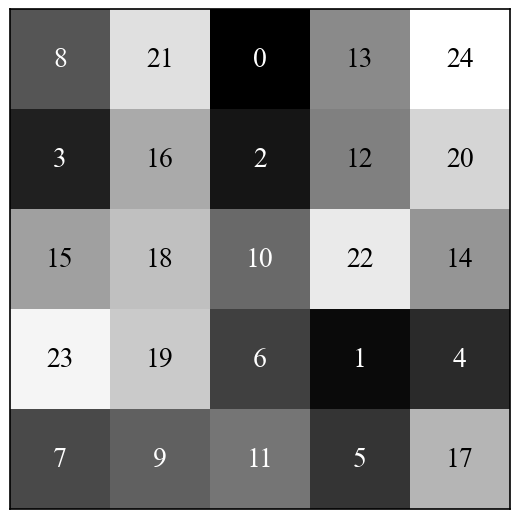

In [9]:
def create_asymmetric_matrix(n, seed=None):
    """
    Creates an n x n matrix with values from 0 to n²-1
    randomly distributed.
    """
    rng = np.random.default_rng(seed)
    values = np.arange(n * n)
    rng.shuffle(values)
    return values.reshape((n, n))


# Example
asymmetric = create_asymmetric_matrix(5, 10)

plt.figure(figsize=(5, 5))

plt.imshow(
    asymmetric,
    cmap="gray",
    origin="lower"
)

plt.xticks([])
plt.yticks([])

# Normalize values for choosing text color
vmin = np.min(asymmetric)
vmax = np.max(asymmetric)

for i in range(asymmetric.shape[0]):
    for j in range(asymmetric.shape[1]):

        value = asymmetric[i, j]

        # Normalize value to [0, 1]
        if vmax > vmin:
            normalized = (value - vmin) / (vmax - vmin)
        else:
            normalized = 0.5

        # Dark background -> white text
        # Bright background -> black text
        text_color = "white" if normalized < 0.5 else "black"

        plt.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            color=text_color,
            fontsize=20
        )

plt.tight_layout(pad=0)

plt.show()

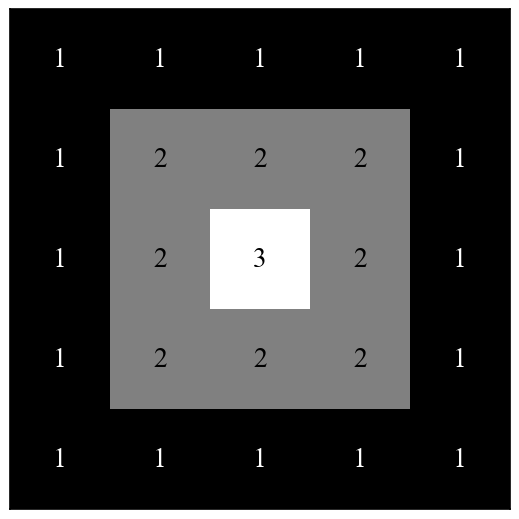

In [10]:
def create_symmetric_matrix(n):
    center = (n - 1) / 2
    matrix = np.zeros((n, n), dtype=int)

    for i in range(n):
        for j in range(n):
            distance = max(abs(i - center), abs(j - center))
            matrix[i, j] = int(center + 1 - distance)

    return matrix


symmetric = create_symmetric_matrix(5)

plt.figure(figsize=(5, 5))

plt.imshow(
    symmetric,
    cmap="gray",
    origin="lower"
)

plt.xticks([])
plt.yticks([])

# Normalize values for choosing text color
vmin = np.min(symmetric)
vmax = np.max(symmetric)

for i in range(symmetric.shape[0]):
    for j in range(symmetric.shape[1]):

        value = symmetric[i, j]

        # Normalize value to [0, 1]
        if vmax > vmin:
            normalized = (value - vmin) / (vmax - vmin)
        else:
            normalized = 0.5

        # Dark background -> white text
        # Bright background -> black text
        text_color = "white" if normalized < 0.5 else "black"

        plt.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            color=text_color,
            fontsize=20
        )

plt.tight_layout(pad=0)

plt.show()

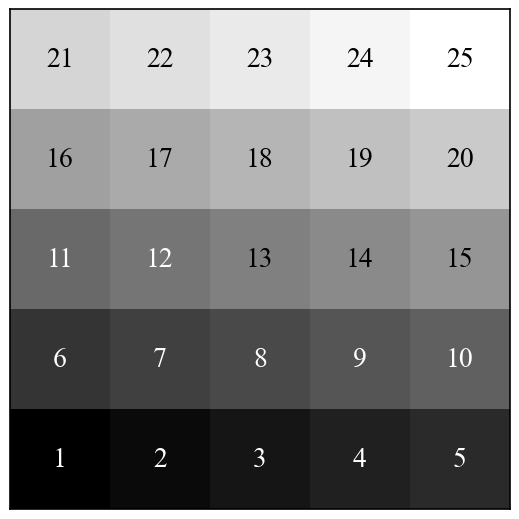

In [11]:
def create_laminar_matrix(n):
    """
    Creates an n x n matrix with increasing values row by row.
    """
    return np.arange(1, n * n + 1).reshape(n, n)


# Example
laminar = create_laminar_matrix(5)

plt.figure(figsize=(5, 5))

plt.imshow(
    laminar,
    cmap="gray",
    origin="lower"
)

plt.xticks([])
plt.yticks([])

# Normalize values for choosing text color
vmin = np.min(laminar)
vmax = np.max(laminar)

for i in range(laminar.shape[0]):
    for j in range(laminar.shape[1]):

        value = laminar[i, j]

        # Normalize value to [0, 1]
        if vmax > vmin:
            normalized = (value - vmin) / (vmax - vmin)
        else:
            normalized = 0.5

        # Dark background -> white text
        # Bright background -> black text
        text_color = "white" if normalized < 0.5 else "black"

        plt.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            color=text_color,
            fontsize=20
        )

plt.tight_layout(pad=0)

plt.show()

In [12]:
print(asymmetric)
gpaObject = GPA(asymmetric)
ga = gpaObject.evaluate()
print(ga)

[[ 7  9 11  5 17]
 [23 19  6  1  4]
 [15 18 10 22 14]
 [ 3 16  2 12 20]
 [ 8 21  0 13 24]]
{'G1': 1.5714285714285714, 'G2': np.float32(1.4220852), 'G3': None, 'G4': None}


/var/folders/25/4ts88tzd08500lbfck1y7nn40000gn/T/ipykernel_46946/1357829969.py:258: UserWarning: angle_tolerance is greater than pi radians. This may cause a large number of gradient vectors to be considered approximately opposite.
  warnings.warn(


## Basic geometric representation

The three visualizations below show the main geometric structures
computed by Gradient Pattern Analysis (GPA) without additional
visual elements.

- **Delaunay triangulation:** represents the spatial connectivity
  between gradient vectors.
- **Gradient field:** shows the original gradient vectors.
- **Asymmetric gradient field:** shows the gradient vectors remaining
  after the removal of radially symmetric contributions.

The image, analysis center, and scale indicator are intentionally
hidden to emphasize the geometric structure of the resulting fields.

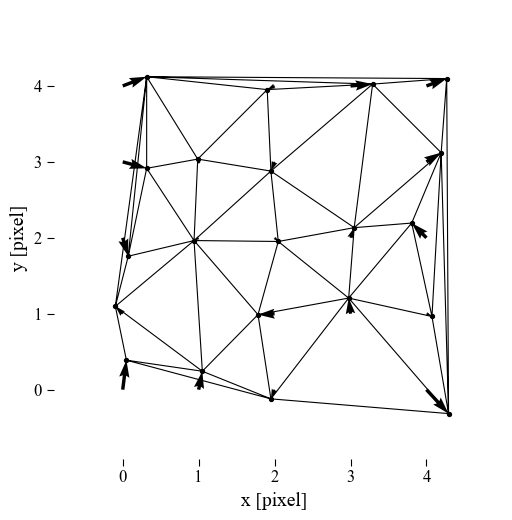

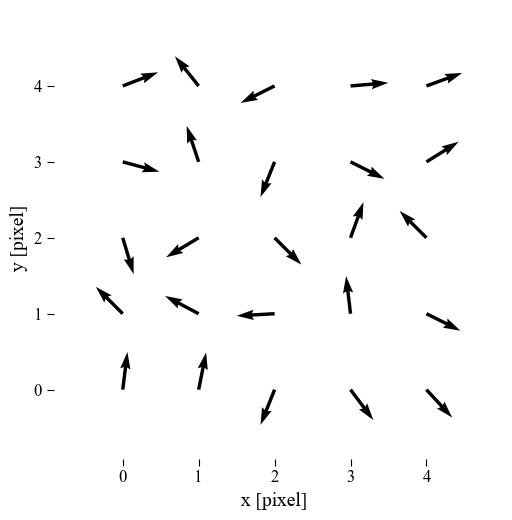

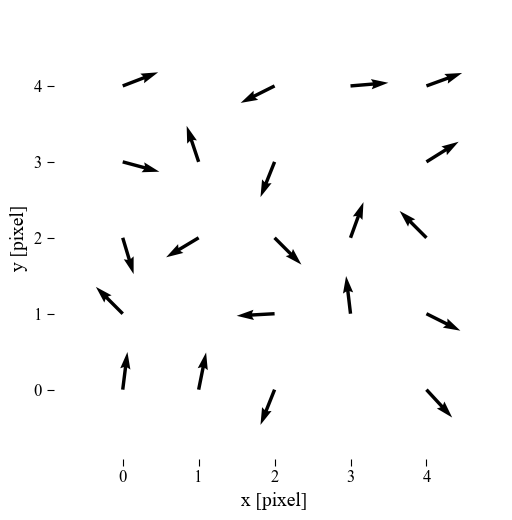

In [13]:
gpaObject.plot_delaunay_triangulation(
    show_center=False,
    show_image=False,
    show_scale=True,
    line_color="black"
)

gpaObject.plot_gradient_field(
    show_center=False,
    show_image=False,
    show_scale=True,
    color="black",
    fixed_length=True
)

gpaObject.plot_asymmetric_gradient_field(
    show_center=False,
    show_image=False,
    show_scale=True,
    color="black",
    fixed_length=True
)

## Gradient magnitude represented by vector length

Here, ``fixed_length=False`` preserves the relative magnitude of each
gradient vector.

Consequently:

- vector **direction** represents the gradient orientation;
- vector **length** represents the relative gradient magnitude.

The Delaunay triangulation is shown together with the two gradient
fields to facilitate comparison between the original and asymmetric
gradient structures.

This representation is useful when both the spatial organization and
the intensity of the local gradients are relevant.

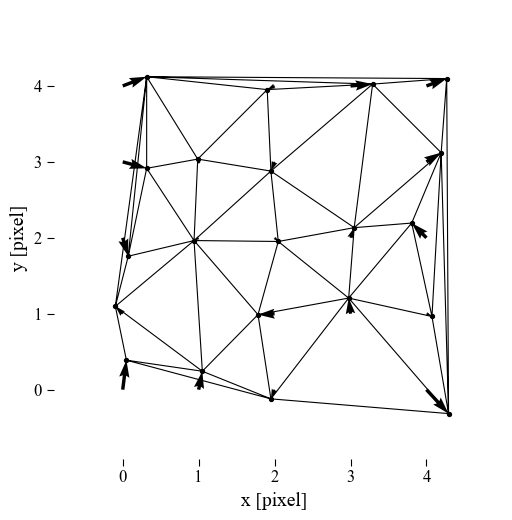

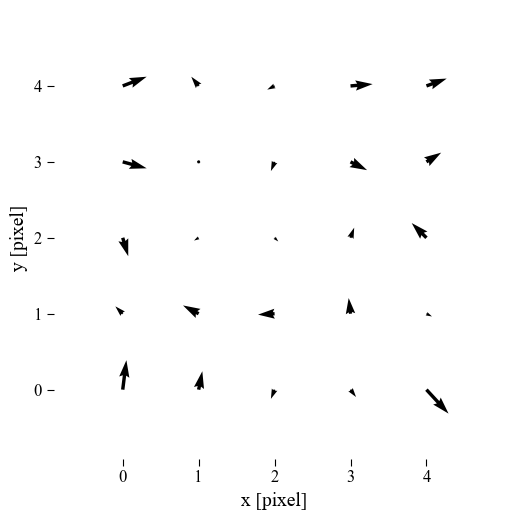

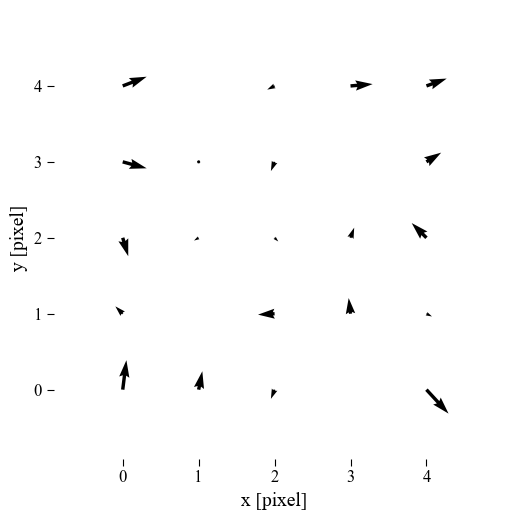

In [14]:
gpaObject.plot_delaunay_triangulation(
    show_center=False,
    show_image=False,
    show_scale=True,
    line_color="black"
)

gpaObject.plot_gradient_field(
    show_center=False,
    show_image=False,
    show_scale=True,
    color="black",
    fixed_length=False
)

gpaObject.plot_asymmetric_gradient_field(
    show_center=False,
    show_image=False,
    show_scale=True,
    color="black",
    fixed_length=False
)

## Gradient structures over the original image

The original image is displayed as the background of all three
visualizations.

The analysis center is also shown, providing a spatial reference for
the radial symmetry analysis performed by GPA.

This representation allows the gradient structures to be directly
related to the underlying image features and illustrates how the
asymmetric gradient field is spatially distributed with respect to
the analysis center.

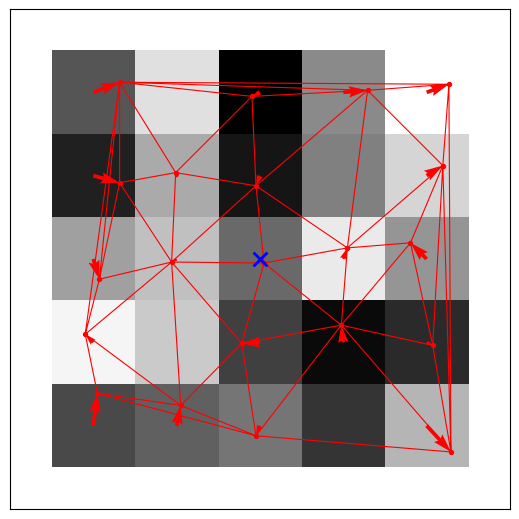

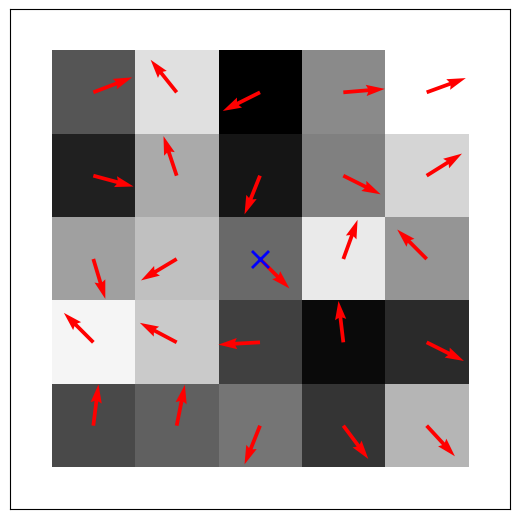

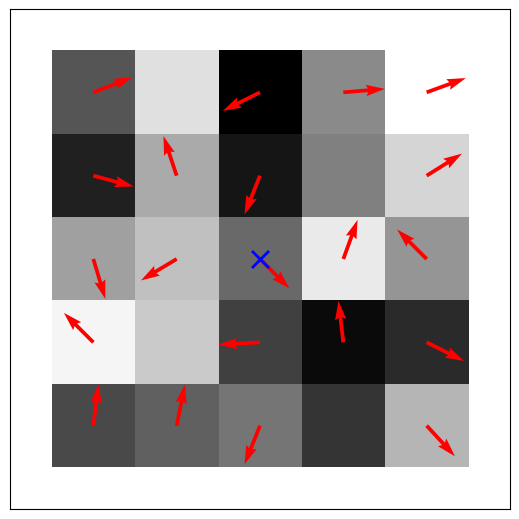

In [15]:
gpaObject.plot_delaunay_triangulation(
    show_center=True,
    show_image=True,
    show_scale=False,
    line_color="red"
)

gpaObject.plot_gradient_field(
    show_center=True,
    show_image=True,
    show_scale=False,
    color="red",
    fixed_length=True
)

gpaObject.plot_asymmetric_gradient_field(
    show_center=True,
    show_image=True,
    show_scale=False,
    color="red",
    fixed_length=True
)

In [16]:
print(symmetric)
gpaObject = GPA(symmetric)
ga = gpaObject.evaluate()
print(ga)

[[1 1 1 1 1]
 [1 2 2 2 1]
 [1 2 3 2 1]
 [1 2 2 2 1]
 [1 1 1 1 1]]
{'G1': 0.0, 'G2': 0.0, 'G3': None, 'G4': None}


/var/folders/25/4ts88tzd08500lbfck1y7nn40000gn/T/ipykernel_46946/1357829969.py:258: UserWarning: angle_tolerance is greater than pi radians. This may cause a large number of gradient vectors to be considered approximately opposite.
  warnings.warn(


No asymmetric gradient vectors remaining.


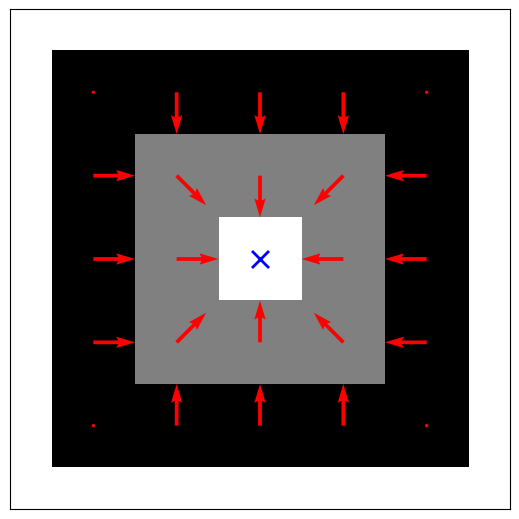

No asymmetric gradient vectors remaining.


In [17]:
gpaObject.plot_delaunay_triangulation(
    show_center=True,
    show_image=True,
    show_scale=False,
    line_color="red"
)

gpaObject.plot_gradient_field(
    show_center=True,
    show_image=True,
    show_scale=False,
    color="red",
    fixed_length=True
)

gpaObject.plot_asymmetric_gradient_field(
    show_center=True,
    show_image=True,
    show_scale=False,
    color="red",
    fixed_length=True
)

In [18]:
print(laminar)
gpaObject = GPA(laminar)
ga = gpaObject.evaluate()
print(ga)

[[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]
 [16 17 18 19 20]
 [21 22 23 24 25]]
{'G1': 1.24, 'G2': np.float32(1.0000002), 'G3': None, 'G4': None}


/var/folders/25/4ts88tzd08500lbfck1y7nn40000gn/T/ipykernel_46946/1357829969.py:258: UserWarning: angle_tolerance is greater than pi radians. This may cause a large number of gradient vectors to be considered approximately opposite.
  warnings.warn(


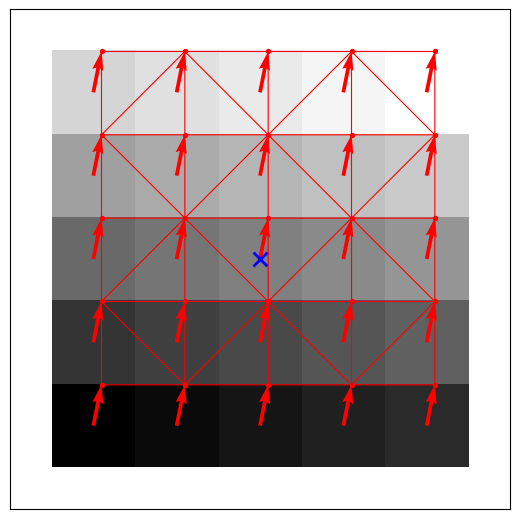

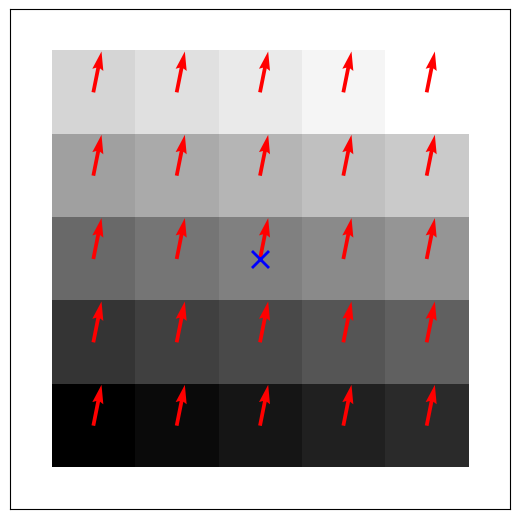

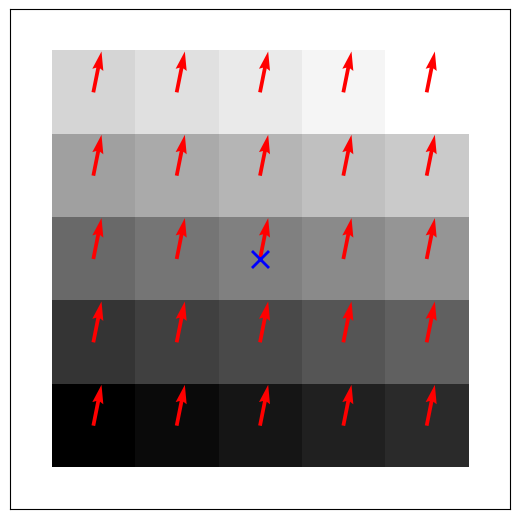

In [19]:
gpaObject.plot_delaunay_triangulation(
    show_center=True,
    show_image=True,
    show_scale=False,
    line_color="red"
)

gpaObject.plot_gradient_field(
    show_center=True,
    show_image=True,
    show_scale=False,
    color="red",
    fixed_length=True
)

gpaObject.plot_asymmetric_gradient_field(
    show_center=True,
    show_image=True,
    show_scale=False,
    color="red",
    fixed_length=True
)

In [20]:
def create_elliptical_galaxy(
    size=51,
    sigma_x=8.0,
    sigma_y=4.5,
    angle=25
):
    """
    Create a rotated elliptical galaxy.

    Parameters
    ----------
    size : int
        Image size.
    sigma_x : float
        Major-axis scale.
    sigma_y : float
        Minor-axis scale.
    angle : float
        Rotation angle in degrees.
    """

    y, x = np.mgrid[0:size, 0:size]

    cx = (size - 1) / 2
    cy = (size - 1) / 2

    # Shift coordinates to the center
    x = x - cx
    y = y - cy

    # Rotation angle
    theta = np.deg2rad(angle)

    # Rotate coordinates
    x_rot = x * np.cos(theta) + y * np.sin(theta)
    y_rot = -x * np.sin(theta) + y * np.cos(theta)

    # Elliptical Gaussian
    matrix = np.exp(
        -(
            (x_rot / sigma_x) ** 2
            + (y_rot / sigma_y) ** 2
        ) / 2
    )

    return matrix

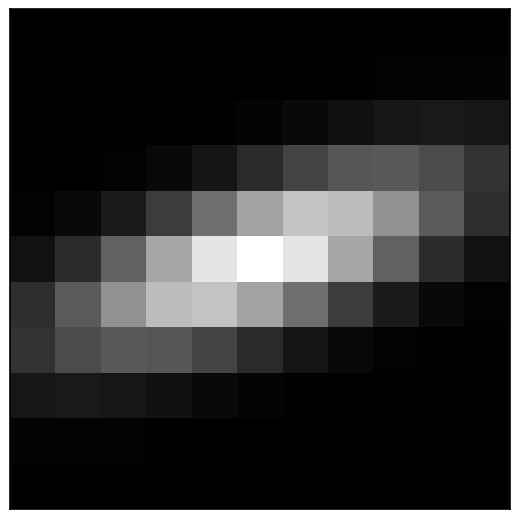

In [21]:
ex = create_elliptical_galaxy(
    size=11,
    sigma_x=3.0,
    sigma_y=1,
    angle=20
)

plt.figure(figsize=(5, 5))

plt.imshow(
    ex,
    cmap="gray",
    origin="lower"
)

plt.xticks([])
plt.yticks([])

plt.tight_layout(pad=0)

plt.show()

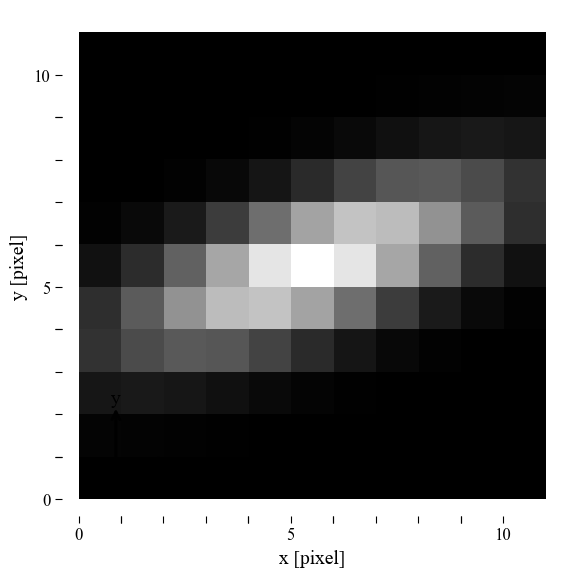

In [22]:
ny, nx = ex.shape[:2]

fig, ax = plt.subplots(figsize=(8, 6))

# Image

ax.imshow(
    ex,
    origin="lower",
    cmap="gray",
    extent=(
        0,
        nx,
        0,
        ny
    )
)

# Plot limits

margin = 0.05 * max(nx, ny)

ax.set_xlim(
    -margin,
    nx + margin
)

ax.set_ylim(
    -margin,
    ny + margin
)
ax.set_aspect("equal")

# Scale

show_scale = True

if show_scale:

    ax.set_xlabel("x [pixel]")
    ax.set_ylabel("y [pixel]")

    # Número de marcações
    n_ticks = 15

    # Ticks
    xticks = np.linspace(
        0,
        nx - 1,
        n_ticks
    ).round().astype(int)

    yticks = np.linspace(
        0,
        ny - 1,
        n_ticks
    ).round().astype(int)

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # Apenas alguns números
    n_labels = 3

    xlabels = np.linspace(
        0,
        n_ticks - 1,
        n_labels
    ).round().astype(int)

    ylabels = np.linspace(
        0,
        n_ticks - 1,
        n_labels
    ).round().astype(int)

    ax.set_xticklabels([
        str(xticks[i]) if i in xlabels else ""
        for i in range(n_ticks)
    ])

    ax.set_yticklabels([
        str(yticks[i]) if i in ylabels else ""
        for i in range(n_ticks)
    ])

    # Remove moldura
    for spine in ax.spines.values():
        spine.set_visible(False)

else:

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlabel("")
    ax.set_ylabel("")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)

# Indicador de orientação

x0 = 0.08 * nx
y0 = 0.08 * ny

arrow_length = 0.12 * min(nx, ny)

# X
ax.annotate(
    "",
    xy=(x0 + arrow_length, y0),
    xytext=(x0, y0),
    arrowprops=dict(
        arrowstyle="->",
        lw=2
    )
)

# Y
ax.annotate(
    "",
    xy=(x0, y0 + arrow_length),
    xytext=(x0, y0),
    arrowprops=dict(
        arrowstyle="->",
        lw=2
    )
)

# Labels
ax.text(
    x0 + arrow_length * 1.05,
    y0,
    "x",
    va="center"
)

ax.text(
    x0,
    y0 + arrow_length * 1.05,
    "y",
    ha="center"
)

plt.tight_layout()
plt.show()

In [23]:
gpaObject = GPA(ex)
ga = gpaObject.evaluate()
print(ga)

{'G1': 0.0, 'G2': 0.0, 'G3': None, 'G4': None}


/var/folders/25/4ts88tzd08500lbfck1y7nn40000gn/T/ipykernel_46946/1357829969.py:258: UserWarning: angle_tolerance is greater than pi radians. This may cause a large number of gradient vectors to be considered approximately opposite.
  warnings.warn(


No asymmetric gradient vectors remaining.


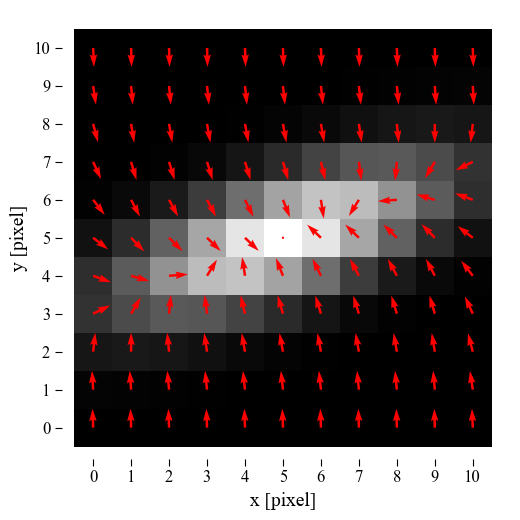

No asymmetric gradient vectors remaining.


In [24]:
gpaObject.plot_delaunay_triangulation(
    show_center=True,
    show_image=True,
    show_scale=True,
    line_color="red"
)

gpaObject.plot_gradient_field(
    show_center=False,
    show_image=True,
    show_scale=True,
    color="red",
    fixed_length=True
)

gpaObject.plot_asymmetric_gradient_field(
    show_center=True,
    show_image=True,
    show_scale=False,
    color="red",
    fixed_length=True
)

In [25]:
from matplotlib.patches import Circle, Arc
from matplotlib.patches import Arc, FancyArrowPatch

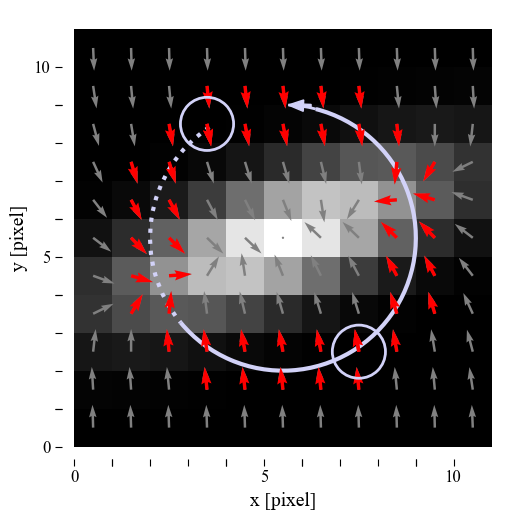

In [26]:
gpaObject.plot_radial_group_pair(
    radius=3.5,
    radial_distance_tolerance=0.9,
    p1=(8, 3),
    p2=(2, 7),
    fixed_length=True,
    show_image=True,
    show_scale=True,
    show_center=False
)

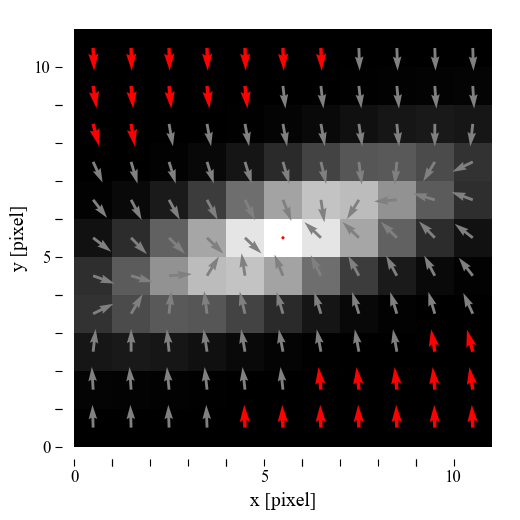

In [27]:
gpaObject.plot_magnitude_threshold(
    threshold=0.01,
    fixed_length=True,
    show_image=True,
    show_scale=True,
    show_center=False
)

In [28]:
import pandas as pd
def create_asymmetric_matrix(n, seed=None):
    """
    Creates an n x n matrix with values from 0 to n²-1
    randomly distributed.
    """
    rng = np.random.default_rng(seed)

    values = np.arange(n * n)

    rng.shuffle(values)

    return values.reshape((n, n))


asymmetric = create_asymmetric_matrix(
    5,
    seed=42
)

In [29]:
sizes = [
    3,
    5,
    10,
    20,
    30,
    40,
    64,
    80,
    100,
    250,
]


def calculate_moments(matrix):

    gpa = GPA(
        matrix.astype(np.float32)
    )

    return gpa.evaluate(
        moments=["G1", "G2"]
    )


n_samples = 10

moments = ["G1", "G2"]

results_scale = []


for size in sizes:

    # Asymmetric: multiple random realizations

    asymmetric_values = {
        moment: []
        for moment in moments
    }

    for seed in range(n_samples):

        asymmetric_matrix = create_asymmetric_matrix(
            size,
            seed=seed
        )

        asymmetric_result = calculate_moments(
            asymmetric_matrix
        )

        for moment in moments:

            asymmetric_values[moment].append(
                asymmetric_result[moment]
            )


    # Laminar: single deterministic realization

    laminar_matrix = create_laminar_matrix(size)

    laminar_result = calculate_moments(
        laminar_matrix
    )


    # Store results

    row = {
        "Size": size
    }

    for moment in moments:

        row[f"Asymmetric_{moment}_mean"] = np.nanmean(
            asymmetric_values[moment]
        )

        row[f"Asymmetric_{moment}_std"] = np.nanstd(
            asymmetric_values[moment]
        )

        row[f"Laminar_{moment}"] = laminar_result[moment]

    results_scale.append(row)


results_scale_df = pd.DataFrame(
    results_scale
)

results_scale_df

/var/folders/25/4ts88tzd08500lbfck1y7nn40000gn/T/ipykernel_46946/1357829969.py:258: UserWarning: angle_tolerance is greater than pi radians. This may cause a large number of gradient vectors to be considered approximately opposite.
  warnings.warn(


,Size,Asymmetric_G1_mean,Asymmetric_G1_std,Laminar_G1,Asymmetric_G2_mean,Asymmetric_G2_std,Laminar_G2
0,3,0.971429,0.171957,0.777778,1.595932,0.120126,1.000000
1,5,1.506054,0.071376,1.240000,1.639234,0.180410,1.000000
2,10,1.838653,0.011261,1.610000,1.806638,0.081202,0.999999
3,20,1.949830,0.009479,1.802500,1.849231,0.028236,0.999997
4,30,1.977736,0.003248,1.867778,1.839038,0.016357,1.000011
5,40,1.984814,0.001605,1.900625,1.846574,0.023596,0.999986
6,64,1.993984,0.000671,1.937744,1.853456,0.017266,0.999939
7,80,1.995801,0.000500,1.950156,1.848180,0.013512,0.999945
8,100,1.997389,0.000318,1.960100,1.850226,0.010007,0.999958
9,250,1.999478,0.000050,1.984016,1.856812,0.003201,0.999992


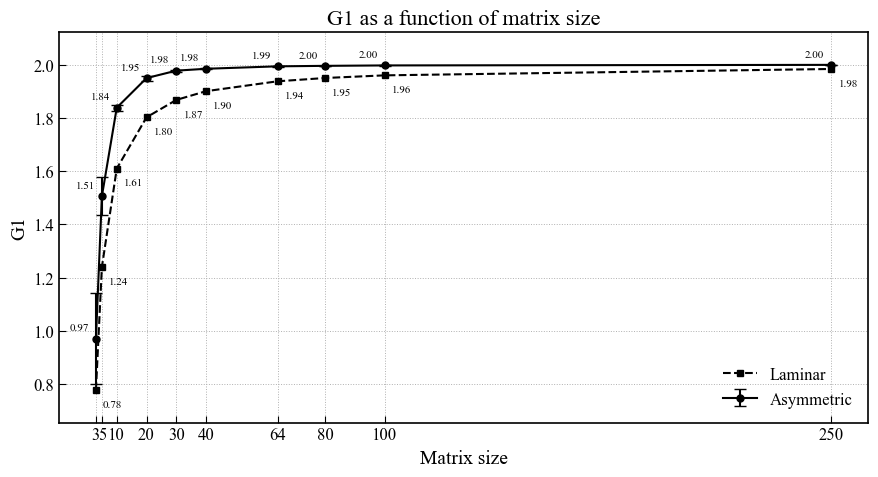

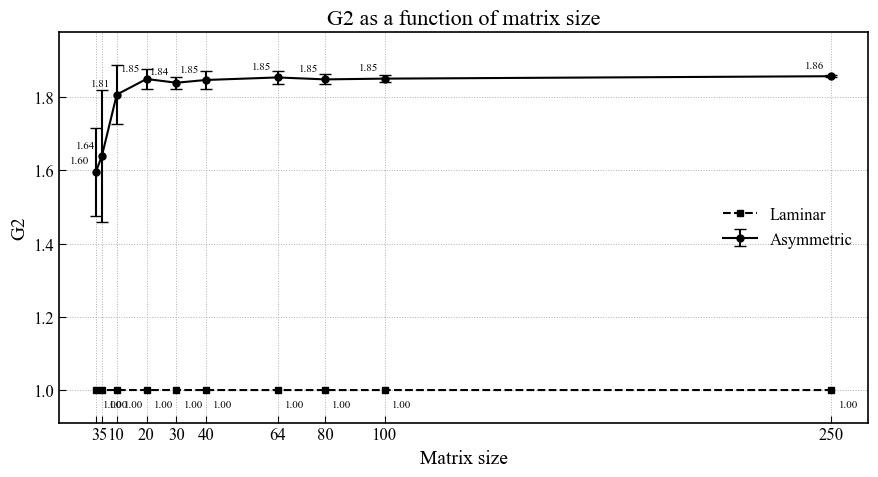

In [30]:
for moment in moments:

    fig, ax = plt.subplots(figsize=(9, 5))

    x = results_scale_df["Size"]

    asymmetric_mean = results_scale_df[
        f"Asymmetric_{moment}_mean"
    ]

    asymmetric_std = results_scale_df[
        f"Asymmetric_{moment}_std"
    ]

    laminar = results_scale_df[
        f"Laminar_{moment}"
    ]

    # Asymmetric: mean ± standard deviation
    ax.errorbar(
        x,
        asymmetric_mean,
        yerr=asymmetric_std,
        color="black",
        linestyle="-",
        marker="o",
        markersize=5,
        capsize=4,
        linewidth=1.5,
        label="Asymmetric"
    )

    # Laminar: deterministic
    ax.plot(
        x,
        laminar,
        color="black",
        linestyle="--",
        marker="s",
        markersize=5,
        linewidth=1.5,
        label="Laminar"
    )

    # Values
    for xi, yi in zip(x, asymmetric_mean):

        ax.annotate(
            f"{yi:.2f}",
            (xi, yi),
            xytext=(-12, 6),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

    for xi, yi in zip(x, laminar):

        ax.annotate(
            f"{yi:.2f}",
            (xi, yi),
            xytext=(12, -12),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

    ax.set_xlabel("Matrix size")
    ax.set_ylabel(moment)

    ax.set_xticks(x)

    ax.grid(
        True,
        linestyle=":",
        linewidth=0.7,
        alpha=1
    )

    ax.legend(
        frameon=False
    )
    
    ax.margins(x=0.05, y=0.1)

    plt.title(
        f"{moment} as a function of matrix size"
    )

    plt.tight_layout()
    plt.show()

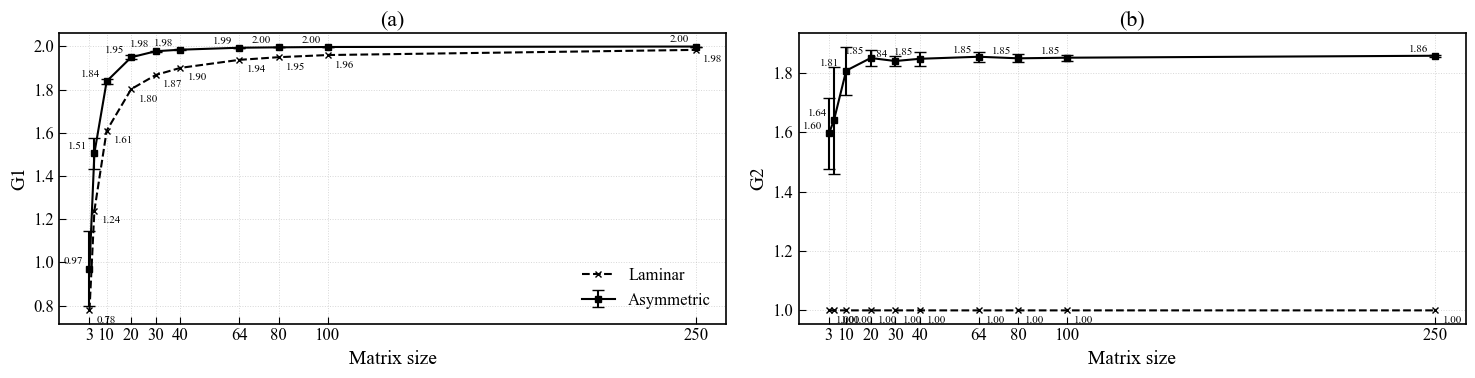

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for ax, moment, label in zip(axes, ["G1", "G2"], ["(a)", "(b)"]):

    x = results_scale_df["Size"]

    asymmetric_mean = results_scale_df[
        f"Asymmetric_{moment}_mean"
    ]

    asymmetric_std = results_scale_df[
        f"Asymmetric_{moment}_std"
    ]

    laminar = results_scale_df[
        f"Laminar_{moment}"
    ]

    # Asymmetric: mean ± standard deviation
    ax.errorbar(
        x,
        asymmetric_mean,
        yerr=asymmetric_std,
        color="black",
        linestyle="-",
        marker="s",
        markersize=5,
        capsize=4,
        linewidth=1.5,
        label="Asymmetric"
    )

    # Laminar: deterministic
    ax.plot(
        x,
        laminar,
        color="black",
        linestyle="--",
        marker="x",
        markersize=5,
        linewidth=1.5,
        label="Laminar"
    )

    # Values
    for xi, yi in zip(x, asymmetric_mean):
        ax.annotate(
            f"{yi:.2f}",
            (xi, yi),
            xytext=(-12, 3),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

    for xi, yi in zip(x, laminar):
        ax.annotate(
            f"{yi:.2f}",
            (xi, yi),
            xytext=(12, -9),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

    ax.set_xlabel("Matrix size")
    ax.set_ylabel(moment)
    ax.set_xticks([size for size in x if size != 5])

    ax.grid(
        True,
        linestyle=":",
        linewidth=0.7,
        alpha=0.5
    )

    if ax == axes[0]:
        ax.legend(frameon=False)

    # # (a) e (b)
    # ax.text(
    #     0.02, 0.98,
    #     label,
    #     transform=ax.transAxes,
    #     ha="left",
    #     va="top",
    #     fontsize=12,
    #     fontweight="bold"
    # )

    ax.set_title("(a)" if moment == "G1" else "(b)")


plt.tight_layout()

plt.savefig(
    "../data/moments_matrix_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()